# Chicago TNP: Hourly H3 Demand Forecasting and Spatial Analysis  
# Chicago TNP：小时级 H3 客流预测与空间分析

This notebook evaluates four connected tasks on completed non-shared Chicago TNP trips: anomaly sensitivity, 1/2/3/6-hour pickup forecasting, pickup/dropoff flow, and first-ring H3 spatial spread. Full-table aggregation runs in MatrixOne; Python receives hourly summaries for modeling and visualization.  
本 Notebook 基于芝加哥 TNP 已完成的非拼车订单，评估四项相互关联的任务：异常敏感度、未来 1/2/3/6 小时上车客流预测、上下车流动关系，以及 H3 一环空间扩散。全表聚合在 MatrixOne 中完成，Python 只接收小时级汇总用于建模和可视化。

## Reproducible configuration / 可复现配置

- Set `CHICAGO_TNP_PROJECT_DIR` to the project output directory. / 使用 `CHICAGO_TNP_PROJECT_DIR` 指定项目输出目录。
- MatrixOne connection values use `MATRIXONE_HOST`, `MATRIXONE_PORT`, `MATRIXONE_USER`, `MATRIXONE_PASSWORD`, and `MATRIXONE_DATABASE`. / MatrixOne 连接通过对应环境变量配置。
- Training uses 2022-2023 and testing uses 2024. / 训练期为 2022-2023，测试期为 2024。
- Demand represents completed trips; supply pressure is a pickup/dropoff proxy rather than observed available drivers. / 客流代表已完成订单；供给压力是基于上下车数量的代理指标，不是真实可用司机数。


## 0. Install dependencies / 安装依赖

Run the next cell once if the packages are missing. Restart the kernel only if Jupyter asks.  
如果缺少依赖，运行下一格一次即可。只有 Jupyter 提示时才需要重启 kernel。


In [1]:
# Cell 1 - Install dependencies / 安装依赖
%pip install -q pandas numpy matplotlib scikit-learn pymysql h3 lightgbm holidays


## 1. Imports and configuration / 导入包和全局配置

The default scope remains the top 50 pickup H3 cells, matching the previous notebook. If memory is limited, reduce `TOP_N_CELLS` to 20 or 30.  
默认继续分析 pickup 最多的 50 个 H3，与之前 Notebook 保持一致。如果内存不足，可以把 `TOP_N_CELLS` 改成 20 或 30。


In [2]:
import os
from getpass import getpass
# Cell 2 - Imports and configuration / 导入包和配置

from pathlib import Path
from datetime import date, timedelta
import calendar
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymysql
import h3
import holidays

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Project path. Raw CSV files are not read directly in this notebook.
# 项目路径。本 Notebook 不直接读取原始 CSV。
# Portable project configuration / 可移植项目配置
PROJECT_DIR = Path(
    os.getenv("CHICAGO_TNP_PROJECT_DIR", str(Path.cwd()))
).expanduser().resolve()
OUTPUT_DIR = PROJECT_DIR / "notebook_outputs_hourly_sensitivity_flow_spatial"
CACHE_DIR = OUTPUT_DIR / "cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# MatrixOne settings / MatrixOne 设置
MO_HOST = os.getenv("MATRIXONE_HOST", "127.0.0.1")
MO_PORT = int(os.getenv("MATRIXONE_PORT", "6001"))
MO_USER = os.getenv("MATRIXONE_USER", "root")
MO_PASSWORD = os.getenv("MATRIXONE_PASSWORD") or getpass("MatrixOne password / MatrixOne 密码: ")
MO_DB = os.getenv("MATRIXONE_DATABASE", "chicago_tnp")
ANALYSIS_TABLE = "unified_trips_h3_res9"
NEIGHBOR_MAP_TABLE = "tnp_analysis_neighbor_map_res9"

# Analysis settings / 分析设置
TOP_N_CELLS = 50
TRAIN_END = pd.Timestamp("2024-01-01")
DATA_START = pd.Timestamp("2022-01-01")
DATA_END = pd.Timestamp("2024-12-31")
FORECAST_HORIZONS = [1, 2, 3, 6]
RANDOM_STATE = 42

# Anomaly thresholds / 异常阈值
HIGH_Z_THRESHOLD = 3.0
LOW_Z_THRESHOLD = -3.0
MIN_PEAK_COUNT = 100
MIN_EXPECTED_FOR_LOW = 30

# Cache large MatrixOne query results after the first run.
# 第一次从 MatrixOne 取数后缓存大结果，方便后续重跑。
REUSE_CACHE = True

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("ANALYSIS_TABLE:", ANALYSIS_TABLE)
print("TOP_N_CELLS:", TOP_N_CELLS)
print("TRAIN_END:", TRAIN_END.date())


PROJECT_DIR: <project_dir>
OUTPUT_DIR: <project_dir>/notebook_outputs_hourly_sensitivity_flow_spatial
ANALYSIS_TABLE: unified_trips_h3_res9
TOP_N_CELLS: 50
TRAIN_END: 2024-01-01


## 2. Connect to MatrixOne / 连接 MatrixOne

MatrixOne performs the full-table scans and aggregation. Jupyter receives only hourly summaries.  
全量扫描和聚合由 MatrixOne 完成，Jupyter 只接收小时级汇总结果。


In [3]:
# Cell 3 - Connect and define SQL helpers / 连接并定义 SQL 工具

def get_conn(database=MO_DB):
    """Open a MatrixOne connection. / 创建 MatrixOne 连接。"""
    # Connect through the MySQL-compatible protocol.
    # 通过 MySQL 兼容协议连接 MatrixOne。
    return pymysql.connect(
        host=MO_HOST,
        port=MO_PORT,
        user=MO_USER,
        password=MO_PASSWORD,
        database=database,
        charset="utf8mb4",
        autocommit=True,
        local_infile=True,
    )


conn = get_conn()
print("Connected to MatrixOne. / 已连接 MatrixOne。")


def query_df(sql, params=None):
    """Run a SQL query and return a pandas DataFrame. / 执行 SQL 查询并返回 pandas DataFrame。"""
    # Run SQL and return a pandas DataFrame.
    # 执行 SQL 并返回 pandas DataFrame。
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return pd.read_sql_query(sql, conn, params=params)


def execute_sql(sql):
    """Execute a SQL statement and commit it. / 执行 SQL 语句并提交事务。"""
    # Run SQL that does not return a table.
    # 执行不返回结果表的 SQL。
    with conn.cursor() as cursor:
        cursor.execute(sql)


def table_exists(table_name):
    """Check whether a MatrixOne table exists. / 检查 MatrixOne 表是否存在。"""
    q = """
    SELECT COUNT(*) AS n
    FROM information_schema.tables
    WHERE table_schema = %s AND table_name = %s
    """
    return int(query_df(q, [MO_DB, table_name]).loc[0, "n"]) > 0


def sql_quote(value):
    """Escape a value for use in a SQL string literal. / 转义 SQL 字符串字面量。"""
    # Quote a string used in an SQL IN list.
    # 给 SQL IN 列表里的字符串加安全引号。
    return "'" + str(value).replace("'", "''") + "'"


Connected to MatrixOne. / 已连接 MatrixOne。


## 3. Validate the full H3 table / 验证全量 H3 表

This is a safety check before the expensive hourly queries.  
在运行较大的小时级查询前，先确认表和关键字段完整。


In [4]:
# Cell 4 - Validate source table / 验证源表

if not table_exists(ANALYSIS_TABLE):
    raise RuntimeError(
        f"Missing table: {ANALYSIS_TABLE}. "
        "Please run the previous H3 build notebook first. / 请先运行之前的 H3 建表 Notebook。"
    )

rows_h3 = query_df(f"SELECT COUNT(*) AS rows_h3 FROM {ANALYSIS_TABLE};")
source_split = query_df(f"""
SELECT source_file, COUNT(*) AS n
FROM {ANALYSIS_TABLE}
GROUP BY source_file
ORDER BY source_file;
""")
schema_df = query_df(f"DESCRIBE {ANALYSIS_TABLE};")

required_columns = {
    "trip_start_timestamp", "trip_end_timestamp", "pickup_h3", "dropoff_h3",
    "trip_seconds", "trip_total", "shared_trip_authorized"
}
actual_columns = set(schema_df["Field"].astype(str))
missing_columns = sorted(required_columns - actual_columns)
if missing_columns:
    raise RuntimeError(f"Missing required columns / 缺少必要字段: {missing_columns}")

display(rows_h3)
display(source_split)
display(schema_df)

rows_h3.to_csv(OUTPUT_DIR / "validation_rows_h3.csv", index=False)
source_split.to_csv(OUTPUT_DIR / "validation_source_split.csv", index=False)
schema_df.to_csv(OUTPUT_DIR / "validation_schema.csv", index=False)


,rows_h3
0,243479296


,source_file,n
0,2022,69109780
1,2023_2024,174369516


,Field,Type,Null,Key,Default,Extra,Comment
0,source_file,VARCHAR(20),YES,,None,,
1,trip_id,VARCHAR(80),YES,,None,,
2,trip_start_timestamp,DATETIME(0),YES,,None,,
3,trip_end_timestamp,DATETIME(0),YES,,None,,
4,trip_seconds,BIGINT(64),YES,,None,,
5,trip_miles,DOUBLE(0),YES,,None,,
6,pickup_community_area,INT(32),YES,,None,,
7,dropoff_community_area,INT(32),YES,,None,,
8,fare,DOUBLE(0),YES,,None,,
9,tip,DOUBLE(0),YES,,None,,


## 4. Select training-period H3 cells and build neighbor mapping / 选择训练期 H3 并建立邻居关系

Top cells are selected using only 2022-2023 data. This prevents the 2024 test period from influencing which cells enter the experiment.  
Top H3 只用 2022-2023 训练期选择，避免 2024 测试数据提前影响实验区域。

For each target H3, we build its resolution-9 first-ring neighbors. The helper mapping table contains only a few hundred rows.  
对每个目标 H3，我们建立 resolution 9 的一环邻居关系。辅助映射表只有几百行。


In [5]:
# Cell 5 - Select top cells and upload H3 neighbor map / 选择 Top H3 并上传邻居映射

top_cells_df = query_df(f"""
SELECT pickup_h3, COUNT(*) AS trip_count
FROM {ANALYSIS_TABLE}
WHERE shared_trip_authorized = 0
  AND pickup_h3 IS NOT NULL
  AND trip_start_timestamp >= '2022-01-01'
  AND trip_start_timestamp < '2024-01-01'
GROUP BY pickup_h3
ORDER BY trip_count DESC
LIMIT {TOP_N_CELLS};
""")

top_cells = top_cells_df["pickup_h3"].astype(str).tolist()
if len(top_cells) != TOP_N_CELLS:
    raise RuntimeError(f"Expected {TOP_N_CELLS} top cells, got {len(top_cells)}")


def first_ring(cell):
    """Return the first H3 ring around a center cell. / 返回中心 H3 单元的一环邻居。"""
    # Support both current and older h3-py APIs.
    # 兼容新旧 h3-py API。
    if hasattr(h3, "grid_disk"):
        cells = set(h3.grid_disk(cell, 1))
    else:
        cells = set(h3.k_ring(cell, 1))
    cells.discard(cell)
    return sorted(cells)


neighbor_rows = []
for target in top_cells:
    for neighbor in first_ring(target):
        neighbor_rows.append((target, neighbor))

neighbor_map = pd.DataFrame(neighbor_rows, columns=["target_h3", "neighbor_h3"])
print("Top cells / Top H3 数量:", len(top_cells))
print("Neighbor map rows / 邻居映射行数:", len(neighbor_map))
display(top_cells_df.head(10))
display(neighbor_map.head(12))

# Rebuild a small helper table used by the MatrixOne neighbor aggregation.
# 重建一个很小的辅助表，供 MatrixOne 聚合周边 H3。
execute_sql(f"DROP TABLE IF EXISTS {NEIGHBOR_MAP_TABLE};")
execute_sql(f"""
CREATE TABLE {NEIGHBOR_MAP_TABLE} (
    target_h3 VARCHAR(32),
    neighbor_h3 VARCHAR(32)
);
""")
with conn.cursor() as cursor:
    cursor.executemany(
        f"INSERT INTO {NEIGHBOR_MAP_TABLE} (target_h3, neighbor_h3) VALUES (%s, %s)",
        neighbor_rows,
    )

top_cells_df.to_csv(OUTPUT_DIR / "top_h3_cells_train_2022_2023.csv", index=False)
neighbor_map.to_csv(OUTPUT_DIR / "h3_first_ring_neighbor_map.csv", index=False)


Top cells / Top H3 数量: 50
Neighbor map rows / 邻居映射行数: 300


,pickup_h3,trip_count
0,89275934ed3ffff,4862218
1,892664c1a8bffff,4108744
2,892664c1e0fffff,3323371
3,892664cad77ffff,3124696
4,892664c1ecfffff,2994326
5,892664c1e2fffff,2981912
6,892664c1e73ffff,2785357
7,892664c1607ffff,2205443
8,892664ca913ffff,2180632
9,892664c1e4fffff,2086838


,target_h3,neighbor_h3
0,89275934ed3ffff,8927593416bffff
1,89275934ed3ffff,8927593416fffff
2,89275934ed3ffff,892759343a7ffff
3,89275934ed3ffff,89275934ec3ffff
4,89275934ed3ffff,89275934ed7ffff
5,89275934ed3ffff,89275934edbffff
6,892664c1a8bffff,892664c1a13ffff
7,892664c1a8bffff,892664c1a83ffff
8,892664c1a8bffff,892664c1a8fffff
9,892664c1a8bffff,892664c1a9bffff


## 5. Import hourly pickup, dropoff, and neighbor demand / 导入小时级 Pickup、Dropoff 与周边需求

Three MatrixOne aggregations are used:

1. pickup counts and trip summaries for each target H3 and start hour;
2. dropoff counts for each target H3 and end hour;
3. total pickup demand across each target H3's first-ring neighbors.

使用三次 MatrixOne 聚合：

1. 每个目标 H3、每个开始小时的 pickup 数量和行程摘要；
2. 每个目标 H3、每个结束小时的 dropoff 数量；
3. 每个目标 H3 一环邻居的 pickup 总量。

The first run may take several minutes. Each year is queried separately, and every completed result is cached immediately. The neighbor calculation avoids a large fact-table join: MatrixOne first aggregates the required neighbor H3 cells, then pandas applies the small H3 map.  
第一次运行可能需要几分钟。代码会按年份分别查询，并在每一步完成后立即保存缓存。邻居计算不再让 MatrixOne 执行大型事实表 JOIN：先聚合需要的邻居 H3，再由 pandas 套用小型 H3 映射表。


In [6]:
# Cell 6 - Query or load hourly aggregates / 查询或载入小时聚合

pickup_cache = CACHE_DIR / f"hourly_pickup_top{TOP_N_CELLS}_cells.csv.gz"
dropoff_cache = CACHE_DIR / f"hourly_dropoff_top{TOP_N_CELLS}_cells.csv.gz"
neighbor_cache = CACHE_DIR / f"hourly_neighbor_pickup_top{TOP_N_CELLS}.csv.gz"

def query_with_reconnect(sql):
    """Run a query and reconnect once after a lost connection. / 查询断线后重连一次并重新执行。"""
    # Reconnect once if MatrixOne closes a long-running client connection.
    # 如果 MatrixOne 关闭了长查询连接，自动重连并重试一次。
    global conn
    try:
        return query_df(sql)
    except pymysql.err.OperationalError as exc:
        if not exc.args or exc.args[0] not in (2006, 2013):
            raise
        print("Connection was lost; reconnecting once. / 连接中断，正在重连并重试一次。")
        try:
            conn.close()
        except Exception:
            pass
        conn = get_conn()
        return query_df(sql)


def query_year_chunks(sql_builder, label):
    """Load an hourly query one year at a time. / 按年份分块读取小时级查询。"""
    # Smaller yearly queries reduce timeout and memory pressure.
    # 按年份查询，降低超时和内存压力。
    parts = []
    for year in [2022, 2023, 2024]:
        print(f"  {label}: {year}")
        parts.append(query_with_reconnect(sql_builder(year)))
    return pd.concat(parts, ignore_index=True)


def current_frame_is_usable(name, required_columns):
    """Validate the current cached DataFrame schema. / 验证当前缓存 DataFrame 的结构。"""
    # Reuse a result that already exists in the current kernel after a later query failed.
    # 如果后续查询失败，允许复用当前 kernel 中已经完成的结果。
    value = globals().get(name)
    return isinstance(value, pd.DataFrame) and required_columns.issubset(value.columns) and not value.empty


quoted_top_cells = ",".join(sql_quote(cell) for cell in top_cells)

if REUSE_CACHE and pickup_cache.exists():
    print("Query 1/3: loading pickup cache / 读取 pickup 缓存")
    pickup_raw = pd.read_csv(pickup_cache, compression="gzip", dtype={"h3": str})
elif current_frame_is_usable("pickup_raw", {"h3", "d", "hour", "pickup_count"}):
    print("Query 1/3: reusing pickup_raw from this kernel / 复用当前 kernel 的 pickup_raw")
    pickup_raw.to_csv(pickup_cache, index=False, compression="gzip")
else:
    print("Query 1/3: hourly pickups by year / 按年份查询小时 pickup")
    pickup_raw = query_year_chunks(
        lambda year: f"""
        SELECT
            pickup_h3 AS h3,
            DATE_FORMAT(trip_start_timestamp, '%Y-%m-%d') AS d,
            CAST(DATE_FORMAT(trip_start_timestamp, '%H') AS INT) AS hour,
            COUNT(*) AS pickup_count,
            AVG(trip_seconds) AS avg_trip_seconds,
            AVG(trip_total) AS avg_trip_total,
            AVG(trip_miles) AS avg_trip_miles
        FROM {ANALYSIS_TABLE}
        WHERE shared_trip_authorized = 0
          AND pickup_h3 IN ({quoted_top_cells})
          AND trip_start_timestamp >= '{year}-01-01'
          AND trip_start_timestamp < '{year + 1}-01-01'
        GROUP BY pickup_h3, d, hour;
        """,
        "pickup",
    )
    pickup_raw.to_csv(pickup_cache, index=False, compression="gzip")

if REUSE_CACHE and dropoff_cache.exists():
    print("Query 2/3: loading dropoff cache / 读取 dropoff 缓存")
    dropoff_raw = pd.read_csv(dropoff_cache, compression="gzip", dtype={"h3": str})
elif current_frame_is_usable("dropoff_raw", {"h3", "d", "hour", "dropoff_count"}):
    print("Query 2/3: reusing dropoff_raw from this kernel / 复用当前 kernel 的 dropoff_raw")
    dropoff_raw.to_csv(dropoff_cache, index=False, compression="gzip")
else:
    print("Query 2/3: hourly dropoffs by year / 按年份查询小时 dropoff")
    dropoff_raw = query_year_chunks(
        lambda year: f"""
        SELECT
            dropoff_h3 AS h3,
            DATE_FORMAT(trip_end_timestamp, '%Y-%m-%d') AS d,
            CAST(DATE_FORMAT(trip_end_timestamp, '%H') AS INT) AS hour,
            COUNT(*) AS dropoff_count
        FROM {ANALYSIS_TABLE}
        WHERE shared_trip_authorized = 0
          AND dropoff_h3 IN ({quoted_top_cells})
          AND trip_end_timestamp >= '{year}-01-01'
          AND trip_end_timestamp < '{year + 1}-01-01'
        GROUP BY dropoff_h3, d, hour;
        """,
        "dropoff",
    )
    dropoff_raw.to_csv(dropoff_cache, index=False, compression="gzip")

if REUSE_CACHE and neighbor_cache.exists():
    print("Query 3/3: loading neighbor cache / 读取邻居缓存")
    neighbor_raw = pd.read_csv(neighbor_cache, compression="gzip", dtype={"h3": str})
elif current_frame_is_usable("neighbor_raw", {"h3", "d", "hour", "neighbor_pickup_count"}):
    print("Query 3/3: reusing neighbor_raw from this kernel / 复用当前 kernel 的 neighbor_raw")
    neighbor_raw.to_csv(neighbor_cache, index=False, compression="gzip")
else:
    print("Query 3/3: neighbor-cell pickups by year, without a large JOIN")
    print("按年份查询邻居 H3，不执行大型 JOIN")
    unique_neighbor_cells = sorted(neighbor_map["neighbor_h3"].astype(str).unique())
    quoted_neighbor_cells = ",".join(sql_quote(cell) for cell in unique_neighbor_cells)

    neighbor_cell_raw = query_year_chunks(
        lambda year: f"""
        SELECT
            pickup_h3 AS neighbor_h3,
            DATE_FORMAT(trip_start_timestamp, '%Y-%m-%d') AS d,
            CAST(DATE_FORMAT(trip_start_timestamp, '%H') AS INT) AS hour,
            COUNT(*) AS neighbor_pickup_count
        FROM {ANALYSIS_TABLE}
        WHERE shared_trip_authorized = 0
          AND pickup_h3 IN ({quoted_neighbor_cells})
          AND trip_start_timestamp >= '{year}-01-01'
          AND trip_start_timestamp < '{year + 1}-01-01'
        GROUP BY pickup_h3, d, hour;
        """,
        "neighbor pickup",
    )

    # Apply the small target-neighbor map in pandas after MatrixOne has aggregated the fact table.
    # MatrixOne 完成事实表聚合后，再在 pandas 中套用小型目标-邻居映射。
    neighbor_cell_raw["neighbor_h3"] = neighbor_cell_raw["neighbor_h3"].astype(str)
    neighbor_expanded = neighbor_map.merge(neighbor_cell_raw, on="neighbor_h3", how="inner")
    neighbor_raw = (
        neighbor_expanded
        .groupby(["target_h3", "d", "hour"], as_index=False)
        .agg(
            neighbor_pickup_count=("neighbor_pickup_count", "sum"),
            active_neighbor_cells=("neighbor_h3", "nunique"),
        )
        .rename(columns={"target_h3": "h3"})
    )
    neighbor_raw.to_csv(neighbor_cache, index=False, compression="gzip")

for frame in [pickup_raw, dropoff_raw, neighbor_raw]:
    frame["d"] = pd.to_datetime(frame["d"])
    frame["hour"] = frame["hour"].astype(int)

print("pickup_raw rows:", len(pickup_raw))
print("dropoff_raw rows:", len(dropoff_raw))
print("neighbor_raw rows:", len(neighbor_raw))
display(pickup_raw.head())
display(dropoff_raw.head())
display(neighbor_raw.head())


Query 1/3: hourly pickups by year / 按年份查询小时 pickup
  pickup: 2022
  pickup: 2023
  pickup: 2024
Query 2/3: hourly dropoffs by year / 按年份查询小时 dropoff
  dropoff: 2022
  dropoff: 2023
  dropoff: 2024
Query 3/3: neighbor-cell pickups by year, without a large JOIN
按年份查询邻居 H3，不执行大型 JOIN
  neighbor pickup: 2022
  neighbor pickup: 2023
  neighbor pickup: 2024
pickup_raw rows: 1295892
dropoff_raw rows: 1288841
neighbor_raw rows: 646232


,h3,d,hour,pickup_count,avg_trip_seconds,avg_trip_total,avg_trip_miles
0,892664c1ecfffff,2022-08-19,0,239,966.096234,27.697029,8.214784
1,892664c1e0fffff,2022-08-19,0,139,661.079137,21.894892,4.113646
2,892664c1acfffff,2022-08-19,0,45,773.977778,26.023111,5.170747
3,892664cc5d7ffff,2022-08-19,0,57,508.666667,12.386491,3.214189
4,892664c1607ffff,2022-08-19,0,142,820.802817,16.137394,5.150808


,h3,d,hour,dropoff_count
0,892664c1607ffff,2022-08-19,0,134
1,892664cae4fffff,2022-08-19,0,36
2,892664c1e0fffff,2022-08-19,0,117
3,892664d8973ffff,2022-08-19,0,71
4,892664cac3bffff,2022-08-19,0,104


,h3,d,hour,neighbor_pickup_count,active_neighbor_cells
0,892664520afffff,2022-01-02,13,1,1
1,892664520afffff,2022-01-03,14,1,1
2,892664520afffff,2022-01-04,7,3,1
3,892664520afffff,2022-01-04,12,2,1
4,892664520afffff,2022-01-04,13,1,1


In [7]:
# Cell 7 - Complete H3 x date x hour grid / 补全 H3 × 日期 × 小时网格

all_days = pd.date_range(DATA_START, DATA_END, freq="D")
all_hours = list(range(24))

hourly_grid = pd.MultiIndex.from_product(
    [top_cells, all_days, all_hours],
    names=["h3", "d", "hour"],
).to_frame(index=False)

hourly = (
    hourly_grid
    .merge(pickup_raw, on=["h3", "d", "hour"], how="left")
    .merge(dropoff_raw, on=["h3", "d", "hour"], how="left")
    .merge(neighbor_raw, on=["h3", "d", "hour"], how="left")
)

count_columns = ["pickup_count", "dropoff_count", "neighbor_pickup_count", "active_neighbor_cells"]
for column in count_columns:
    hourly[column] = hourly[column].fillna(0).astype("int32")

hourly["timestamp"] = hourly["d"] + pd.to_timedelta(hourly["hour"], unit="h")
hourly["year"] = hourly["d"].dt.year.astype("int16")
hourly["month"] = hourly["d"].dt.month.astype("int8")
hourly["day"] = hourly["d"].dt.day.astype("int8")
hourly["day_of_year"] = hourly["d"].dt.dayofyear.astype("int16")
hourly["dow_mon0"] = hourly["d"].dt.dayofweek.astype("int8")
hourly["dow_sun0"] = ((hourly["dow_mon0"] + 1) % 7).astype("int8")
hourly["is_weekend"] = (hourly["dow_mon0"] >= 5).astype("int8")

us_holidays = holidays.US(years=[2022, 2023, 2024])
hourly["is_holiday"] = hourly["d"].dt.date.map(lambda x: int(x in us_holidays)).astype("int8")


def nth_weekday(year, month, weekday, n):
    """Return the nth requested weekday in a month. / 返回某月第 n 个指定星期日期。"""
    first = date(year, month, 1)
    shift = (weekday - first.weekday()) % 7
    return first + timedelta(days=shift + 7 * (n - 1))


dst_start_dates = {nth_weekday(year, 3, calendar.SUNDAY, 2) for year in [2022, 2023, 2024]}
hourly["is_dst_missing_hour"] = (
    hourly["d"].dt.date.isin(dst_start_dates) & (hourly["hour"] == 2)
).astype("int8")

print("Complete hourly rows / 完整小时行数:", len(hourly))
print("Date range / 日期范围:", hourly["d"].min().date(), "->", hourly["d"].max().date())
print("Zero pickup-hour ratio / pickup 为 0 的小时比例:", round((hourly["pickup_count"] == 0).mean() * 100, 3), "%")
display(hourly.head())

# Pickle is used only as an internal rerun cache because it is faster and smaller than a huge CSV.
# Pickle 只作为内部重跑缓存，比大型 CSV 更快、更小。
hourly.to_pickle(CACHE_DIR / "hourly_complete_grid.pkl")


Complete hourly rows / 完整小时行数: 1315200
Date range / 日期范围: 2022-01-01 -> 2024-12-31
Zero pickup-hour ratio / pickup 为 0 的小时比例: 1.468 %


,h3,d,hour,pickup_count,avg_trip_seconds,avg_trip_total,avg_trip_miles,dropoff_count,neighbor_pickup_count,active_neighbor_cells,timestamp,year,month,day,day_of_year,dow_mon0,dow_sun0,is_weekend,is_holiday,is_dst_missing_hour
0,89275934ed3ffff,2022-01-01,0,66,1671.803030,63.352727,20.059733,4,0,0,2022-01-01 00:00:00,2022,1,1,1,5,6,1,1,0
1,89275934ed3ffff,2022-01-01,1,49,1528.489796,70.557551,18.109751,0,0,0,2022-01-01 01:00:00,2022,1,1,1,5,6,1,1,0
2,89275934ed3ffff,2022-01-01,2,37,1527.054054,69.982703,18.881146,14,0,0,2022-01-01 02:00:00,2022,1,1,1,5,6,1,1,0
3,89275934ed3ffff,2022-01-01,3,22,1668.136364,57.240000,21.309691,55,0,0,2022-01-01 03:00:00,2022,1,1,1,5,6,1,1,0
4,89275934ed3ffff,2022-01-01,4,0,NaN,NaN,NaN,144,0,0,2022-01-01 04:00:00,2022,1,1,1,5,6,1,1,0


## 6. Direction 1 - Anomaly magnitude, direction, and sensitivity / 方向一：异常程度、方向与敏感度

The original z-score is still useful, but one number is not enough:

```text
pickup_z > 0: above normal / 高于正常
pickup_z < 0: below normal / 低于正常
abs_z: anomaly magnitude only / 只表示异常有多大
delta_z_1h: how quickly the anomaly changed / 异常变化速度
z_acceleration: whether the change itself is accelerating / 变化是否还在加速
```

We retain both direction and magnitude. Using only the absolute value would incorrectly treat a surge and a collapse as the same event.  
我们同时保留方向和大小。只用绝对值会把暴涨和暴跌错误地当成同一种情况。


In [8]:
# Cell 8 - Historical baselines and dynamic anomaly features / 历史基线与动态异常特征

train_hourly = hourly[hourly["d"] < TRAIN_END].copy()

baseline = train_hourly.groupby(["h3", "dow_sun0", "hour"]).agg(
    expected_pickup=("pickup_count", "mean"),
    std_pickup=("pickup_count", "std"),
    expected_dropoff=("dropoff_count", "mean"),
    std_dropoff=("dropoff_count", "std"),
    expected_trip_seconds=("avg_trip_seconds", "mean"),
).reset_index()

for column in ["std_pickup", "std_dropoff"]:
    baseline[column] = baseline[column].replace(0, np.nan).fillna(1.0).clip(lower=1.0)

scored = hourly.merge(baseline, on=["h3", "dow_sun0", "hour"], how="left")
scored["pickup_z"] = (scored["pickup_count"] - scored["expected_pickup"]) / scored["std_pickup"]
scored["dropoff_z"] = (scored["dropoff_count"] - scored["expected_dropoff"]) / scored["std_dropoff"]
scored["abs_z"] = scored["pickup_z"].abs()
scored["actual_to_expected"] = scored["pickup_count"] / scored["expected_pickup"].replace(0, np.nan)

scored = scored.sort_values(["h3", "timestamp"]).reset_index(drop=True)
grouped = scored.groupby("h3", sort=False)

scored["pickup_change_1h"] = grouped["pickup_count"].diff()
scored["pickup_pct_change_1h"] = grouped["pickup_count"].pct_change(fill_method=None)
scored["pickup_pct_change_1h"] = scored["pickup_pct_change_1h"].replace([np.inf, -np.inf], np.nan).clip(-5, 5)
scored["delta_z_1h"] = grouped["pickup_z"].diff()
scored["z_velocity_3h"] = grouped["delta_z_1h"].transform(
    lambda s: s.rolling(3, min_periods=1).mean()
)
scored["z_acceleration"] = grouped["delta_z_1h"].diff()

scored["is_high_peak"] = (
    (scored["pickup_z"] >= HIGH_Z_THRESHOLD)
    & (scored["pickup_count"] >= MIN_PEAK_COUNT)
).astype("int8")
scored["is_low_anomaly"] = (
    (scored["pickup_z"] <= LOW_Z_THRESHOLD)
    & (scored["expected_pickup"] >= MIN_EXPECTED_FOR_LOW)
    & (scored["is_dst_missing_hour"] == 0)
).astype("int8")

# Refresh the groupby object after adding new columns.
# 新增异常标记列后重新建立 groupby，避免旧对象看不到新列。
grouped = scored.groupby("h3", sort=False)

scored["trend_state"] = np.select(
    [
        (scored["pickup_z"] >= HIGH_Z_THRESHOLD) & (scored["delta_z_1h"] > 1),
        (scored["pickup_z"] >= HIGH_Z_THRESHOLD),
        (scored["pickup_z"] <= LOW_Z_THRESHOLD) & (scored["delta_z_1h"] < -1),
        (scored["pickup_z"] <= LOW_Z_THRESHOLD),
        (scored["delta_z_1h"] > 1),
        (scored["delta_z_1h"] < -1),
    ],
    ["rapid_high_rise", "high", "rapid_low_drop", "low", "rising", "falling"],
    default="normal",
)

# Count consecutive high-peak hours within a cell.
# 统计同一 H3 连续高峰已经持续几个小时。
high_group_break = (
    (scored["is_high_peak"] != grouped["is_high_peak"].shift(1))
    | (scored["timestamp"] != grouped["timestamp"].shift(1) + pd.Timedelta(hours=1))
).astype("int32")
scored["high_run_id"] = high_group_break.groupby(scored["h3"]).cumsum()
scored["peak_age_hours"] = 0
high_mask = scored["is_high_peak"] == 1
scored.loc[high_mask, "peak_age_hours"] = (
    scored.loc[high_mask]
    .groupby(["h3", "high_run_id"])
    .cumcount()
    .add(1)
    .astype("int16")
)

scored_2024 = scored[scored["d"] >= TRAIN_END].copy()

print("2024 high peaks:", int(scored_2024["is_high_peak"].sum()))
print("2024 low anomalies:", int(scored_2024["is_low_anomaly"].sum()))
display(scored_2024["trend_state"].value_counts().rename_axis("trend_state").reset_index(name="n"))

baseline.to_csv(OUTPUT_DIR / "hourly_pickup_dropoff_baseline_train.csv", index=False)
scored_2024.to_csv(OUTPUT_DIR / "hourly_dynamic_scores_2024.csv.gz", index=False, compression="gzip")
scored.to_pickle(CACHE_DIR / "hourly_scored_dynamic.pkl")


2024 high peaks: 4282
2024 low anomalies: 652


,trend_state,n
0,normal,297120
1,falling,68700
2,rising,65590
3,rapid_high_rise,4477
4,high,2625
5,rapid_low_drop,383
6,low,305


Fastest rises / 最快上涨：


,h3,timestamp,pickup_count,expected_pickup,pickup_z,abs_z,delta_z_1h,z_velocity_3h,z_acceleration,pickup_pct_change_1h,trend_state
259825,892664c1a87ffff,2024-08-20 01:00:00,346,50.269231,31.021764,31.021764,26.917198,10.549872,25.161615,1.746032,rapid_high_rise
416376,892664c1b0bffff,2024-06-28 00:00:00,498,32.490385,24.047846,24.047846,21.968239,7.729746,20.206746,1.203540,rapid_high_rise
919033,892664ca993ffff,2024-10-26 01:00:00,214,38.990476,13.401792,13.401792,11.572090,4.268547,11.026748,0.725806,rapid_high_rise
920636,892664ca993ffff,2024-12-31 20:00:00,280,52.019231,19.958037,19.958037,11.397527,5.215110,9.208366,0.238938,rapid_high_rise
311016,892664c1aa7ffff,2024-06-22 00:00:00,619,59.057143,12.585991,12.585991,10.093533,4.121552,9.584262,0.892966,rapid_high_rise
259848,892664c1a87ffff,2024-08-21 00:00:00,239,85.259615,9.884791,9.884791,9.613912,3.224213,8.832819,1.133929,rapid_high_rise
102187,892664c114fffff,2024-08-27 19:00:00,230,63.500000,9.589326,9.589326,9.197701,3.180284,8.352909,2.285714,rapid_high_rise
1207247,892664d8973ffff,2024-09-08 23:00:00,146,55.647619,8.934451,8.934451,9.094268,3.243151,9.474481,1.807692,rapid_high_rise
917471,892664ca993ffff,2024-08-21 23:00:00,276,30.817308,10.599544,10.599544,9.001219,3.190400,8.920373,2.538462,rapid_high_rise
390937,892664c1adbffff,2024-08-03 01:00:00,336,79.380952,13.438294,13.438294,8.959816,4.203737,6.150570,0.365854,rapid_high_rise


Fastest drops / 最快下降：


,h3,timestamp,pickup_count,expected_pickup,pickup_z,abs_z,delta_z_1h,z_velocity_3h,z_acceleration,pickup_pct_change_1h,trend_state
1157357,892664cf617ffff,2024-12-31 05:00:00,37,30.038462,1.286955,1.286955,-23.050100,-4.383902,-1.014501,-0.723881,falling
259826,892664c1a87ffff,2024-08-20 02:00:00,123,39.105769,10.742550,10.742550,-20.279214,2.797856,-47.196413,-0.644509,high
22230,892664520afffff,2024-07-15 06:00:00,54,33.855769,1.705289,1.705289,-13.268711,-2.414340,-15.553405,-0.517857,falling
1284820,89275934333ffff,2024-07-15 04:00:00,99,32.596154,4.262702,4.262702,-11.045396,0.473051,-17.756251,-0.673267,high
420574,892664c1b0bffff,2024-12-19 22:00:00,215,91.028846,1.974692,1.974692,-9.981360,-0.327374,-17.053586,-0.634354,falling
1284797,89275934333ffff,2024-07-14 05:00:00,50,55.466667,-0.305650,0.305650,-8.972967,-0.932525,-14.616712,-0.418605,falling
889216,892664ca913ffff,2024-06-01 16:00:00,131,127.923810,0.192852,0.192852,-8.839036,-0.354907,-16.472868,-0.478088,falling
650632,892664c1eabffff,2024-03-16 16:00:00,197,100.019048,4.387617,4.387617,-8.645393,-3.115348,-5.064036,-0.452778,high
893305,892664ca913ffff,2024-11-19 01:00:00,144,77.144231,3.576428,3.576428,-8.087301,0.878757,-12.248150,-0.627907,high
629016,892664c1ea7ffff,2024-09-28 00:00:00,59,38.742857,0.476129,0.476129,-8.041695,-0.638553,-12.392093,-0.868009,falling


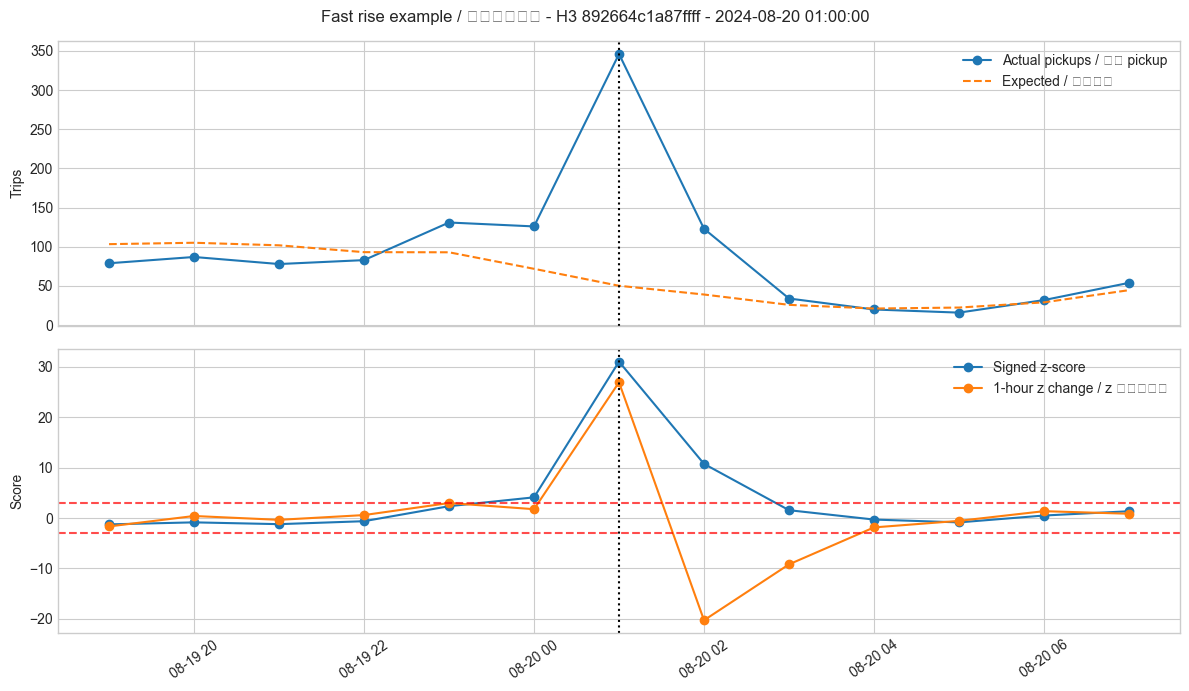

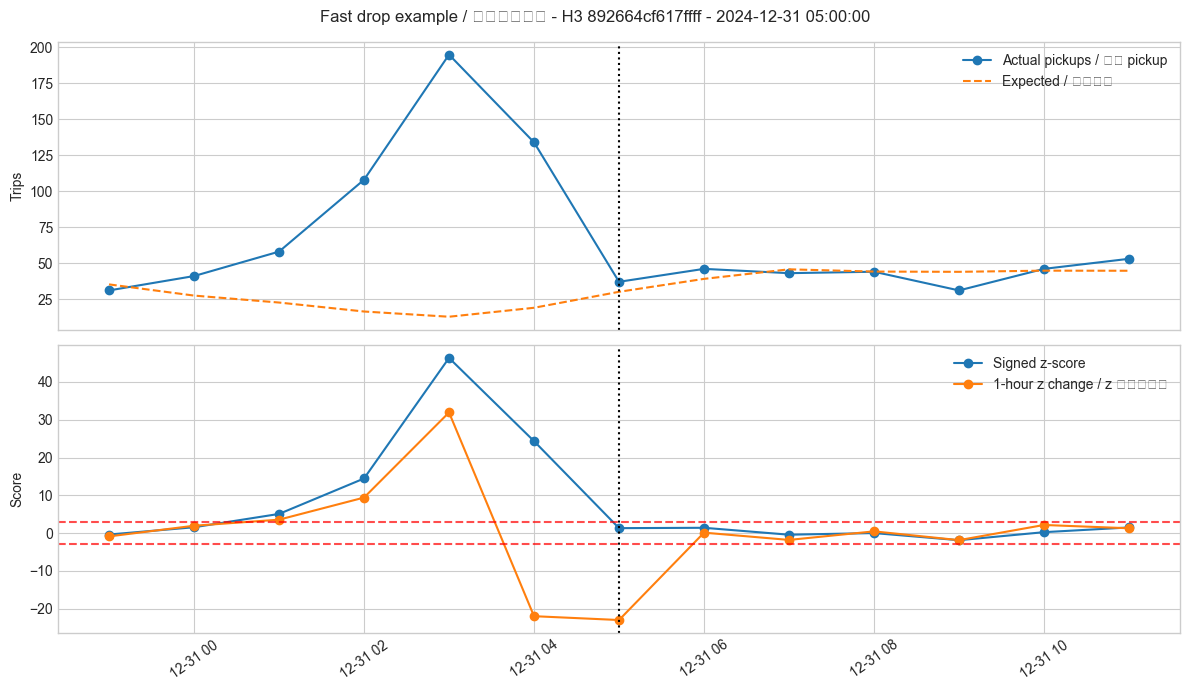

In [9]:
# Cell 9 - Inspect fastest rises and drops / 检查最快上涨和下降

valid_2024 = scored_2024[
    (scored_2024["is_dst_missing_hour"] == 0)
    & (scored_2024["expected_pickup"] >= MIN_EXPECTED_FOR_LOW)
].copy()

top_rapid_rises = valid_2024.nlargest(30, "delta_z_1h")[[
    "h3", "timestamp", "pickup_count", "expected_pickup", "pickup_z", "abs_z",
    "delta_z_1h", "z_velocity_3h", "z_acceleration", "pickup_pct_change_1h", "trend_state"
]]
top_rapid_drops = valid_2024.nsmallest(30, "delta_z_1h")[[
    "h3", "timestamp", "pickup_count", "expected_pickup", "pickup_z", "abs_z",
    "delta_z_1h", "z_velocity_3h", "z_acceleration", "pickup_pct_change_1h", "trend_state"
]]

print("Fastest rises / 最快上涨：")
display(top_rapid_rises.head(15))
print("Fastest drops / 最快下降：")
display(top_rapid_drops.head(15))

top_rapid_rises.to_csv(OUTPUT_DIR / "top_rapid_rises_2024.csv", index=False)
top_rapid_drops.to_csv(OUTPUT_DIR / "top_rapid_drops_2024.csv", index=False)


def plot_dynamic_event(row, title):
    """Plot the demand path around a selected event. / 绘制选定事件前后的需求变化。"""
    cell = row["h3"]
    center = pd.Timestamp(row["timestamp"])
    sub = scored_2024[
        (scored_2024["h3"] == cell)
        & (scored_2024["timestamp"].between(center - pd.Timedelta(hours=6), center + pd.Timedelta(hours=6)))
    ].copy()

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(sub["timestamp"], sub["pickup_count"], marker="o", label="Actual pickups / 实际 pickup")
    axes[0].plot(sub["timestamp"], sub["expected_pickup"], linestyle="--", label="Expected / 历史期望")
    axes[0].axvline(center, color="black", linestyle=":")
    axes[0].set_ylabel("Trips")
    axes[0].legend()

    axes[1].plot(sub["timestamp"], sub["pickup_z"], marker="o", label="Signed z-score")
    axes[1].plot(sub["timestamp"], sub["delta_z_1h"], marker="o", label="1-hour z change / z 一小时变化")
    axes[1].axhline(HIGH_Z_THRESHOLD, color="red", linestyle="--", alpha=0.7)
    axes[1].axhline(LOW_Z_THRESHOLD, color="red", linestyle="--", alpha=0.7)
    axes[1].axvline(center, color="black", linestyle=":")
    axes[1].set_ylabel("Score")
    axes[1].legend()
    fig.suptitle(f"{title} - H3 {cell} - {center}")
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()


plot_dynamic_event(top_rapid_rises.iloc[0], "Fast rise example / 快速上涨示例")
plot_dynamic_event(top_rapid_drops.iloc[0], "Fast drop example / 快速下降示例")


## 7. Direction 2 - Predict demand 1, 2, 3, and 6 hours ahead / 方向二：预测未来 1、2、3、6 小时需求

Prediction origin is the end of the current hour. Therefore, the current pickup count is the one-hour lag for the `horizon=1` target.  
预测时点是当前小时结束时。因此对于 `horizon=1`，当前 pickup 数量就是目标前一小时的 lag。

Direct models are trained separately for each horizon. This avoids repeatedly feeding one-step predictions back into the model.  
每个预测跨度分别训练一个直接模型，避免把一步预测反复传回模型造成误差累积。

The lag sensitivity test changes one input while holding the other inputs fixed. It is a model-response diagnostic, not a causal estimate.  
Lag 敏感度测试只改变一个输入、保持其他输入不变。它用于检查模型反应，不代表因果效果。


In [10]:
# Cell 10 - Build leakage-safe forecasting features / 构造避免泄漏的预测特征

model_df = scored.copy().sort_values(["h3", "timestamp"]).reset_index(drop=True)
model_df["cell_code"] = model_df["h3"].astype("category").cat.codes.astype("int16")

# Cyclical calendar features / 周期性日历特征
model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24)
model_df["dow_sin"] = np.sin(2 * np.pi * model_df["dow_mon0"] / 7)
model_df["dow_cos"] = np.cos(2 * np.pi * model_df["dow_mon0"] / 7)
model_df["doy_sin"] = np.sin(2 * np.pi * model_df["day_of_year"] / 365.25)
model_df["doy_cos"] = np.cos(2 * np.pi * model_df["day_of_year"] / 365.25)

g_pickup = model_df.groupby("h3", sort=False)["pickup_count"]
g_dropoff = model_df.groupby("h3", sort=False)["dropoff_count"]

# Current-hour values are known at prediction time.
# 当前小时结束后，这些值在预测时已经可知。
model_df["pickup_now"] = model_df["pickup_count"]
model_df["dropoff_now"] = model_df["dropoff_count"]

for lag in [1, 2, 3, 6, 24, 168]:
    model_df[f"pickup_lag_{lag}h"] = g_pickup.shift(lag)
    model_df[f"dropoff_lag_{lag}h"] = g_dropoff.shift(lag)

for window in [3, 6, 24, 168]:
    model_df[f"pickup_roll_mean_{window}h"] = model_df.groupby("h3")["pickup_count"].transform(
        lambda s: s.shift(1).rolling(window, min_periods=max(2, window // 3)).mean()
    )
    model_df[f"pickup_roll_std_{window}h"] = model_df.groupby("h3")["pickup_count"].transform(
        lambda s: s.shift(1).rolling(window, min_periods=max(2, window // 3)).std()
    )

# Pickup/dropoff flow features are prepared now and tested separately in Direction 3.
# 这里先准备 pickup/dropoff 流动特征，在方向三单独测试它们的增量价值。
model_df["net_flow"] = model_df["dropoff_count"] - model_df["pickup_count"]
model_df["dropoff_to_pickup_ratio"] = model_df["dropoff_count"] / model_df["pickup_count"].replace(0, np.nan)
for window in [3, 6, 24]:
    model_df[f"net_flow_roll_{window}h"] = model_df.groupby("h3")["net_flow"].transform(
        lambda s: s.shift(1).rolling(window, min_periods=2).sum()
    )

for horizon in FORECAST_HORIZONS:
    model_df[f"target_pickup_h{horizon}"] = model_df.groupby("h3")["pickup_count"].shift(-horizon)
    model_df[f"target_expected_h{horizon}"] = model_df.groupby("h3")["expected_pickup"].shift(-horizon)
    model_df[f"target_std_h{horizon}"] = model_df.groupby("h3")["std_pickup"].shift(-horizon)
    model_df[f"target_peak_h{horizon}"] = model_df.groupby("h3")["is_high_peak"].shift(-horizon)
    model_df[f"target_dst_h{horizon}"] = model_df.groupby("h3")["is_dst_missing_hour"].shift(-horizon)
    model_df[f"target_timestamp_h{horizon}"] = model_df["timestamp"] + pd.Timedelta(hours=horizon)

    # Same target hour one week earlier. This is a fair seasonal naive baseline.
    # 目标小时对应的一周前数值，作为公平的 seasonal naive baseline。
    model_df[f"naive_weekly_h{horizon}"] = model_df.groupby("h3")["pickup_count"].shift(168 - horizon)

calendar_features = [
    "cell_code", "hour", "dow_mon0", "month", "day_of_year",
    "is_weekend", "is_holiday", "hour_sin", "hour_cos",
    "dow_sin", "dow_cos", "doy_sin", "doy_cos",
]

demand_dynamic_features = [
    "pickup_now", "pickup_lag_1h", "pickup_lag_2h", "pickup_lag_3h",
    "pickup_lag_6h", "pickup_lag_24h", "pickup_lag_168h",
    "pickup_roll_mean_3h", "pickup_roll_mean_6h", "pickup_roll_mean_24h",
    "pickup_roll_mean_168h", "pickup_roll_std_3h", "pickup_roll_std_6h",
    "pickup_roll_std_24h", "pickup_roll_std_168h",
    "expected_pickup", "std_pickup", "pickup_z", "abs_z", "delta_z_1h",
    "z_velocity_3h", "z_acceleration", "pickup_pct_change_1h", "peak_age_hours",
]

flow_features = [
    "dropoff_now", "dropoff_lag_1h", "dropoff_lag_2h", "dropoff_lag_3h",
    "dropoff_lag_6h", "dropoff_lag_24h", "dropoff_lag_168h", "dropoff_z",
    "net_flow", "dropoff_to_pickup_ratio", "net_flow_roll_3h",
    "net_flow_roll_6h", "net_flow_roll_24h",
]

base_features = calendar_features + demand_dynamic_features
print("Base features / 基础特征数量:", len(base_features))
print("Flow features / 流动特征数量:", len(flow_features))


Base features / 基础特征数量: 37
Flow features / 流动特征数量: 13


In [11]:
# Cell 11 - Model and evaluation helpers / 模型与评估工具

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except Exception as exc:
    HAS_LIGHTGBM = False
    print("LightGBM unavailable; using HistGradientBoostingRegressor. / LightGBM 不可用，改用 sklearn。")
    print(repr(exc))


def make_model():
    """Create the configured gradient-boosting model. / 创建配置好的梯度提升模型。"""
    if HAS_LIGHTGBM:
        return lgb.LGBMRegressor(
            objective="regression_l1",
            n_estimators=220,
            learning_rate=0.05,
            num_leaves=63,
            min_child_samples=80,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )
    return HistGradientBoostingRegressor(
        loss="absolute_error",
        max_iter=220,
        learning_rate=0.06,
        max_leaf_nodes=63,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    )


def regression_metrics(y_true, y_pred):
    """Calculate regression evaluation metrics. / 计算回归评价指标。"""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mean_y = y_true.mean()
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
        "MAE_pct_of_mean": mae / mean_y * 100 if mean_y else np.nan,
    }


def peak_classification_metrics(y_true_peak, y_pred_peak):
    """Calculate peak-classification metrics. / 计算高峰分类指标。"""
    y_true_peak = np.asarray(y_true_peak, dtype=int)
    y_pred_peak = np.asarray(y_pred_peak, dtype=int)
    return {
        "peak_accuracy": accuracy_score(y_true_peak, y_pred_peak),
        "peak_precision": precision_score(y_true_peak, y_pred_peak, zero_division=0),
        "peak_recall": recall_score(y_true_peak, y_pred_peak, zero_division=0),
        "peak_F1": f1_score(y_true_peak, y_pred_peak, zero_division=0),
    }


model_runs = {}


def evaluate_predictions(name, horizon, frame, indices, predictions):
    """Evaluate count forecasts and peak labels together. / 同时评估客流预测与高峰标签。"""
    target = frame.loc[indices, f"target_pickup_h{horizon}"].to_numpy(dtype=float)
    predictions = np.clip(np.asarray(predictions, dtype=float), 0, None)
    metrics = regression_metrics(target, predictions)

    expected = frame.loc[indices, f"target_expected_h{horizon}"].to_numpy(dtype=float)
    std = frame.loc[indices, f"target_std_h{horizon}"].to_numpy(dtype=float)
    predicted_peak = ((predictions >= expected + HIGH_Z_THRESHOLD * std) & (predictions >= MIN_PEAK_COUNT)).astype(int)
    true_peak = frame.loc[indices, f"target_peak_h{horizon}"].to_numpy(dtype=int)
    metrics.update(peak_classification_metrics(true_peak, predicted_peak))
    metrics.update({"model": name, "horizon_hours": horizon, "test_rows": len(indices)})
    return metrics


def run_model_experiment(name, horizon, features):
    """Train and evaluate one feature-set experiment. / 训练并评估一组特征实验。"""
    target_col = f"target_pickup_h{horizon}"
    target_ts_col = f"target_timestamp_h{horizon}"
    target_dst_col = f"target_dst_h{horizon}"

    valid = (
        model_df[target_col].notna()
        & model_df[target_ts_col].notna()
        & (model_df["is_dst_missing_hour"] == 0)
        & (model_df[target_dst_col].fillna(0) == 0)
    )
    train_mask = valid & (model_df[target_ts_col] < TRAIN_END)
    test_mask = valid & (model_df[target_ts_col] >= TRAIN_END) & (model_df[target_ts_col] < pd.Timestamp("2025-01-01"))

    train_index = model_df.index[train_mask]
    test_index = model_df.index[test_mask]
    medians = model_df.loc[train_index, features].replace([np.inf, -np.inf], np.nan).median()

    X_train = model_df.loc[train_index, features].replace([np.inf, -np.inf], np.nan).fillna(medians).astype("float32")
    X_test = model_df.loc[test_index, features].replace([np.inf, -np.inf], np.nan).fillna(medians).astype("float32")
    y_train = model_df.loc[train_index, target_col].astype("float32")

    started = time.time()
    model = make_model()
    model.fit(X_train, y_train)
    predictions = np.clip(model.predict(X_test), 0, None)
    elapsed = time.time() - started

    metrics = evaluate_predictions(name, horizon, model_df, test_index, predictions)
    metrics["train_rows"] = len(train_index)
    metrics["fit_seconds"] = elapsed

    model_runs[(name, horizon)] = {
        "model": model,
        "features": list(features),
        "medians": medians,
        "test_index": test_index,
        "predictions": predictions,
        "metrics": metrics,
    }
    return metrics


In [12]:
# Cell 12 - Train base models for 1, 2, 3, and 6 hours / 训练 1、2、3、6 小时基础模型

base_metric_rows = []

for horizon in FORECAST_HORIZONS:
    target_col = f"target_pickup_h{horizon}"
    target_ts_col = f"target_timestamp_h{horizon}"
    valid_test = (
        model_df[target_col].notna()
        & (model_df[target_ts_col] >= TRAIN_END)
        & (model_df[target_ts_col] < pd.Timestamp("2025-01-01"))
        & (model_df["is_dst_missing_hour"] == 0)
        & (model_df[f"target_dst_h{horizon}"].fillna(0) == 0)
    )
    test_indices = model_df.index[valid_test]

    # Persistence baseline: use the current completed hour.
    # Persistence 基准：直接使用当前已完成小时的客流。
    base_metric_rows.append(evaluate_predictions(
        "Naive current-hour / 当前小时基准",
        horizon,
        model_df,
        test_indices,
        model_df.loc[test_indices, "pickup_now"],
    ))

    # Seasonal baseline: use the same target hour one week earlier.
    # 周期基准：使用目标小时的一周前客流。
    weekly_valid = test_indices[model_df.loc[test_indices, f"naive_weekly_h{horizon}"].notna()]
    base_metric_rows.append(evaluate_predictions(
        "Naive last-week / 上周同期基准",
        horizon,
        model_df,
        weekly_valid,
        model_df.loc[weekly_valid, f"naive_weekly_h{horizon}"],
    ))

    print(f"Training base model for horizon={horizon}h / 训练 {horizon} 小时模型")
    base_metric_rows.append(run_model_experiment(
        "GBM base dynamic / GBM 基础动态特征",
        horizon,
        base_features,
    ))

base_metrics = pd.DataFrame(base_metric_rows).sort_values(["horizon_hours", "MAE"])
display(base_metrics.round(4))
base_metrics.to_csv(OUTPUT_DIR / "multi_horizon_base_model_metrics.csv", index=False)


Training base model for horizon=1h / 训练 1 小时模型
Training base model for horizon=2h / 训练 2 小时模型
Training base model for horizon=3h / 训练 3 小时模型
Training base model for horizon=6h / 训练 6 小时模型


,MAE,RMSE,R2,MAE_pct_of_mean,peak_accuracy,peak_precision,peak_recall,peak_F1,model,horizon_hours,test_rows,train_rows,fit_seconds
2,13.0115,24.9376,0.9385,13.9730,0.9903,0.5017,0.2131,0.2992,GBM base dynamic / GBM 基础动态特征,1,439100,875750.0,8.4026
1,19.1971,40.6005,0.8371,20.6156,0.9820,0.0625,0.0603,0.0614,Naive last-week / 上周同期基准,1,439100,NaN,NaN
0,20.0470,36.2047,0.8705,21.5284,0.9740,0.1763,0.4531,0.2538,Naive current-hour / 当前小时基准,1,439100,NaN,NaN
5,15.3329,30.9105,0.9056,16.4653,0.9885,0.2572,0.0958,0.1396,GBM base dynamic / GBM 基础动态特征,2,439100,875700.0,8.3152
4,19.1988,40.6065,0.8371,20.6167,0.9820,0.0625,0.0603,0.0614,Naive last-week / 上周同期基准,2,439100,NaN,NaN
3,30.4001,55.4128,0.6966,32.6452,0.9471,0.0700,0.3604,0.1172,Naive current-hour / 当前小时基准,2,439100,NaN,NaN
8,16.2911,33.4934,0.8891,17.4939,0.9883,0.1809,0.0565,0.0861,GBM base dynamic / GBM 基础动态特征,3,439100,875650.0,8.4780
7,19.1995,40.6074,0.8371,20.6171,0.9820,0.0625,0.0603,0.0614,Naive last-week / 上周同期基准,3,439100,NaN,NaN
6,39.5491,71.8747,0.4895,42.4691,0.9258,0.0424,0.3059,0.0745,Naive current-hour / 当前小时基准,3,439100,NaN,NaN
11,16.9279,35.5560,0.8751,18.1780,0.9880,0.1020,0.0299,0.0462,GBM base dynamic / GBM 基础动态特征,6,439100,875500.0,7.6196


,pickup_now_remaining_pct,average_prediction,average_prediction_change,average_prediction_change_pct,median_absolute_response
0,100.0,90.5533,0.0000,0.0000,0.0000
1,90.0,85.6170,-4.9363,-4.7611,2.3523
2,70.0,74.8362,-15.7171,-15.1819,7.4651
3,50.0,62.7167,-27.8366,-26.6833,13.2013
4,30.0,50.6184,-39.9348,-37.6193,18.8568


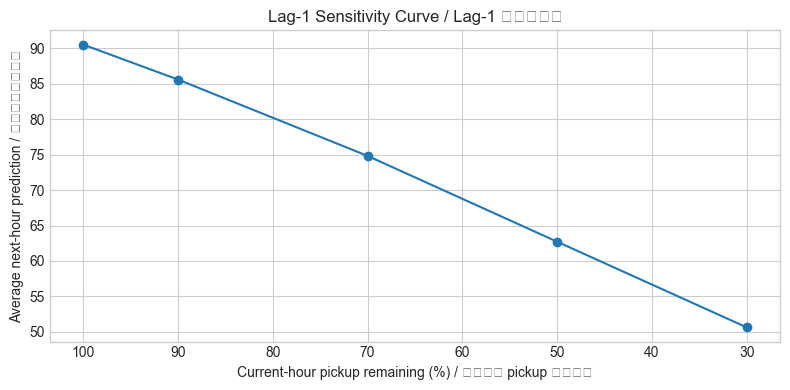

,feature,importance
0,cell_code,1329
1,hour,1253
7,hour_sin,1158
28,expected_pickup,923
8,hour_cos,898
29,std_pickup,842
13,pickup_now,765
35,pickup_pct_change_1h,569
27,pickup_roll_std_168h,555
32,delta_z_1h,546


In [13]:
# Cell 13 - Quantify one-hour lag sensitivity / 量化一小时 lag 敏感度

# For the 1-hour target, pickup_now is exactly the previous hour's observed pickup count.
# 对未来 1 小时目标，pickup_now 就是目标前一小时的已观测 pickup。
h1_run = model_runs[("GBM base dynamic / GBM 基础动态特征", 1)]
h1_test_index = h1_run["test_index"]

sample_n = min(30000, len(h1_test_index))
sensitivity_index = pd.Index(h1_test_index).to_series().sample(sample_n, random_state=RANDOM_STATE).to_numpy()
X_sensitivity = (
    model_df.loc[sensitivity_index, h1_run["features"]]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(h1_run["medians"])
    .astype("float32")
)
base_prediction = np.clip(h1_run["model"].predict(X_sensitivity), 0, None)

sensitivity_rows = []
for remaining_fraction in [1.0, 0.9, 0.7, 0.5, 0.3]:
    scenario = X_sensitivity.copy()
    scenario["pickup_now"] = scenario["pickup_now"] * remaining_fraction
    scenario_prediction = np.clip(h1_run["model"].predict(scenario), 0, None)
    sensitivity_rows.append({
        "pickup_now_remaining_pct": remaining_fraction * 100,
        "average_prediction": scenario_prediction.mean(),
        "average_prediction_change": (scenario_prediction - base_prediction).mean(),
        "average_prediction_change_pct": (
            (scenario_prediction - base_prediction) / np.maximum(base_prediction, 1)
        ).mean() * 100,
        "median_absolute_response": np.median(np.abs(scenario_prediction - base_prediction)),
    })

lag_sensitivity = pd.DataFrame(sensitivity_rows)
display(lag_sensitivity.round(4))
lag_sensitivity.to_csv(OUTPUT_DIR / "lag1_sensitivity_scenarios.csv", index=False)

plt.figure(figsize=(8, 4))
plt.plot(lag_sensitivity["pickup_now_remaining_pct"], lag_sensitivity["average_prediction"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("Current-hour pickup remaining (%) / 当前小时 pickup 剩余比例")
plt.ylabel("Average next-hour prediction / 下一小时平均预测")
plt.title("Lag-1 Sensitivity Curve / Lag-1 敏感度曲线")
plt.tight_layout()
plt.show()

# Feature importance / 特征重要性
if hasattr(h1_run["model"], "feature_importances_"):
    importance_values = h1_run["model"].feature_importances_
else:
    small_n = min(5000, len(X_sensitivity))
    small_X = X_sensitivity.iloc[:small_n]
    small_y = model_df.loc[sensitivity_index[:small_n], "target_pickup_h1"]
    importance_values = permutation_importance(
        h1_run["model"], small_X, small_y, n_repeats=3, random_state=RANDOM_STATE,
        scoring="neg_mean_absolute_error"
    ).importances_mean

h1_importance = pd.DataFrame({"feature": h1_run["features"], "importance": importance_values})
h1_importance = h1_importance.sort_values("importance", ascending=False)
display(h1_importance.head(25))
h1_importance.to_csv(OUTPUT_DIR / "h1_base_feature_importance.csv", index=False)


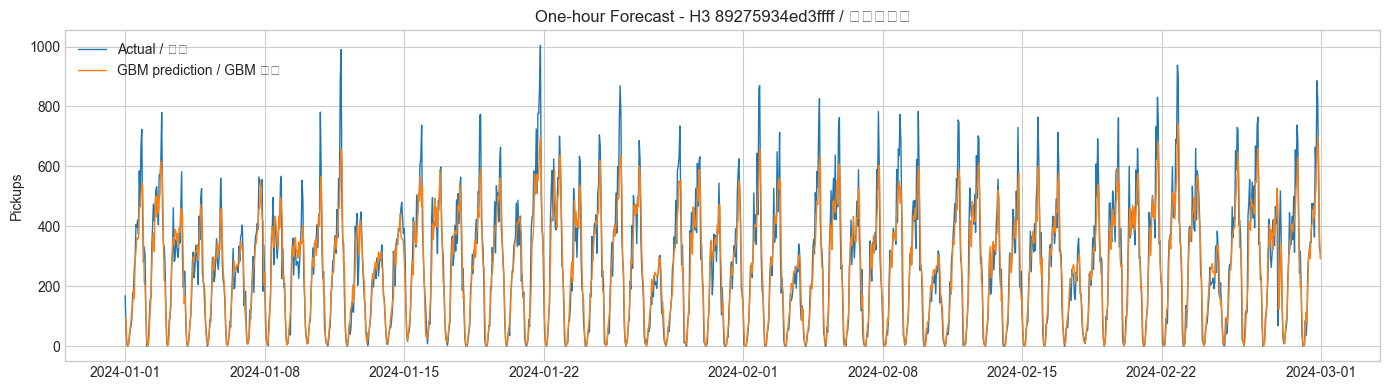

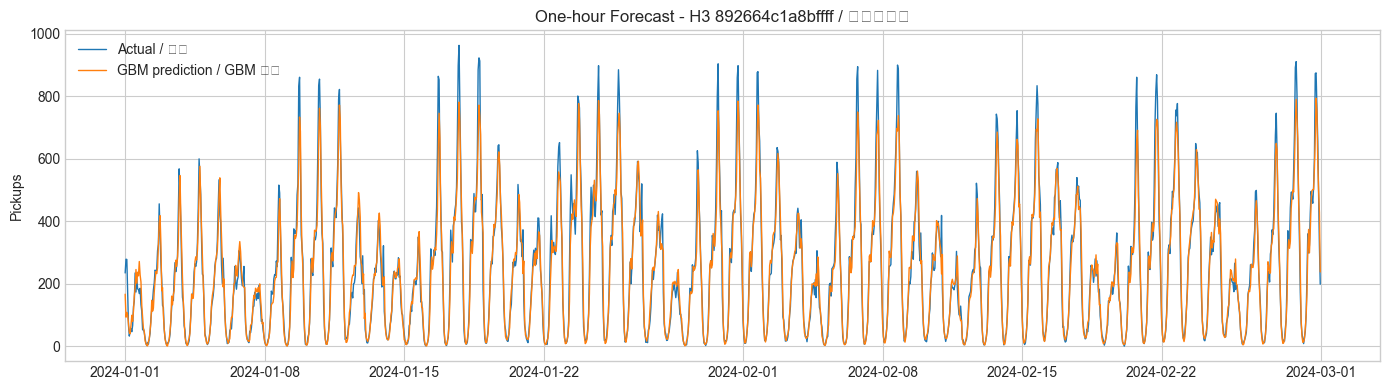

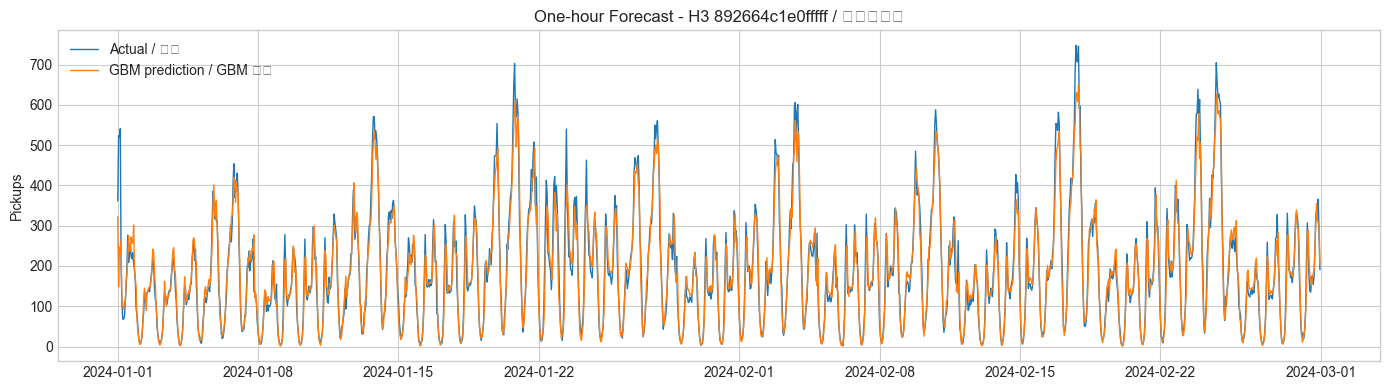

In [14]:
# Cell 14 - Plot actual vs predicted hourly demand / 画实际值与预测值

h1_plot = model_df.loc[h1_run["test_index"], ["h3", "target_timestamp_h1", "target_pickup_h1"]].copy()
h1_plot["prediction"] = h1_run["predictions"]

plot_cells = (
    h1_plot.groupby("h3")["target_pickup_h1"]
    .sum().nlargest(3).index.tolist()
)

for cell in plot_cells:
    sub = h1_plot[h1_plot["h3"] == cell].sort_values("target_timestamp_h1")
    # Show the first 60 test days so hourly lines remain readable.
    # 只显示测试期前 60 天，让小时曲线保持可读。
    cutoff = sub["target_timestamp_h1"].min() + pd.Timedelta(days=60)
    sub = sub[sub["target_timestamp_h1"] < cutoff]

    plt.figure(figsize=(14, 4))
    plt.plot(sub["target_timestamp_h1"], sub["target_pickup_h1"], linewidth=1, label="Actual / 实际")
    plt.plot(sub["target_timestamp_h1"], sub["prediction"], linewidth=1, label="GBM prediction / GBM 预测")
    plt.title(f"One-hour Forecast - H3 {cell} / 一小时预测")
    plt.ylabel("Pickups")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 8. Direction 3 - Pickup/dropoff lead-lag and supply-pressure proxy / 方向三：上下车领先关系与供给压力代理

We remove the normal weekday-hour pattern first, then test whether an unusual dropoff increase is followed by an unusual pickup increase.  
我们先扣除正常的星期-小时规律，再测试异常 dropoff 上升是否会在之后带来异常 pickup 上升。

`dropoff lead = 2 hours` means dropoff z-score at time `t-2` is compared with pickup z-score at time `t`.  
`dropoff lead = 2 hours` 表示用 `t-2` 时刻的 dropoff z-score 对比 `t` 时刻的 pickup z-score。


,period,dropoff_lead_hours,correlation_dropoff_z_to_pickup_z,rows
0,train_2022_2023,0,0.4266,876000
1,train_2022_2023,1,0.3739,875950
2,train_2022_2023,2,0.3473,875900
3,train_2022_2023,3,0.3197,875850
4,train_2022_2023,4,0.2896,875800
5,train_2022_2023,5,0.2630,875750
6,train_2022_2023,6,0.2445,875700
7,test_2024,0,0.4485,439200
8,test_2024,1,0.3959,439150
9,test_2024,2,0.3430,439100


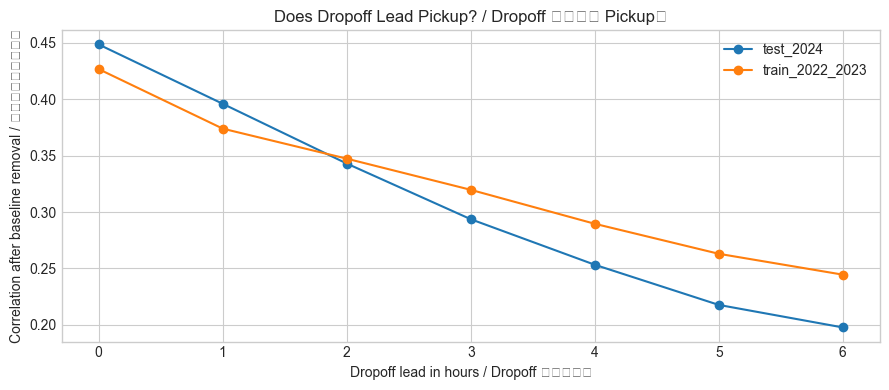

,h3,dropoff_lead_hours,correlation,abs_correlation
20,892664c1e4fffff,0,0.718413,0.718413
16,892664c1e0fffff,0,0.709669,0.709669
18,892664c1e2fffff,0,0.661339,0.661339
21,892664c1e73ffff,0,0.632626,0.632626
10,892664c1a8bffff,0,0.624026,0.624026
14,892664c1adbffff,0,0.617220,0.617220
19,892664c1e33ffff,0,0.603480,0.603480
36,892664cad77ffff,1,0.591418,0.591418
5,892664c13afffff,0,0.574213,0.574213
17,892664c1e13ffff,0,0.554070,0.554070


In [15]:
# Cell 15 - Cross-lag relationship between dropoffs and pickups / Dropoff 与 Pickup 的跨时滞关系

lag_rows = []
for period_name, period_mask in [
    ("train_2022_2023", model_df["d"] < TRAIN_END),
    ("test_2024", model_df["d"] >= TRAIN_END),
]:
    period = model_df.loc[period_mask, ["h3", "dropoff_z", "pickup_z"]].copy()
    for lead_hours in range(0, 7):
        dropoff_lead = period.groupby("h3")["dropoff_z"].shift(lead_hours)
        valid = dropoff_lead.notna() & period["pickup_z"].notna()
        lag_rows.append({
            "period": period_name,
            "dropoff_lead_hours": lead_hours,
            "correlation_dropoff_z_to_pickup_z": dropoff_lead[valid].corr(period.loc[valid, "pickup_z"]),
            "rows": int(valid.sum()),
        })

dropoff_pickup_lag = pd.DataFrame(lag_rows)
display(dropoff_pickup_lag.round(4))
dropoff_pickup_lag.to_csv(OUTPUT_DIR / "dropoff_to_pickup_cross_lag_correlation.csv", index=False)

plt.figure(figsize=(9, 4))
for period_name, sub in dropoff_pickup_lag.groupby("period"):
    plt.plot(sub["dropoff_lead_hours"], sub["correlation_dropoff_z_to_pickup_z"], marker="o", label=period_name)
plt.xlabel("Dropoff lead in hours / Dropoff 领先小时数")
plt.ylabel("Correlation after baseline removal / 扣除基线后的相关性")
plt.title("Does Dropoff Lead Pickup? / Dropoff 是否领先 Pickup？")
plt.legend()
plt.tight_layout()
plt.show()

# Best lag for each H3 in 2024 / 每个 H3 在 2024 年的最佳 lag
test_period = model_df[model_df["d"] >= TRAIN_END].copy()
cell_lag_rows = []
for cell, sub in test_period.groupby("h3", sort=False):
    for lead_hours in range(0, 7):
        x = sub["dropoff_z"].shift(lead_hours)
        valid = x.notna() & sub["pickup_z"].notna()
        cell_lag_rows.append({
            "h3": cell,
            "dropoff_lead_hours": lead_hours,
            "correlation": x[valid].corr(sub.loc[valid, "pickup_z"]),
        })

cell_lag = pd.DataFrame(cell_lag_rows)
best_cell_lag = (
    cell_lag.assign(abs_correlation=cell_lag["correlation"].abs())
    .sort_values(["h3", "abs_correlation"], ascending=[True, False])
    .groupby("h3", as_index=False).first()
)
display(best_cell_lag.sort_values("abs_correlation", ascending=False).head(20))
best_cell_lag.to_csv(OUTPUT_DIR / "best_dropoff_lead_by_h3_2024.csv", index=False)


Top relative inflow / 最大相对净流入：


,h3,timestamp,pickup_count,dropoff_count,net_flow,expected_net_flow,supply_pressure_z,pickup_z,dropoff_z
102773,892664c114fffff,2024-09-21 05:00:00,6,145,139,-3.276190,36.376014,0.172069,56.951872
96435,892664c114fffff,2024-01-01 03:00:00,70,133,63,0.067308,31.913764,47.777585,63.744854
102774,892664c114fffff,2024-09-21 06:00:00,15,210,195,-3.838095,24.586123,0.945300,33.239471
596210,892664c1e8fffff,2024-01-01 02:00:00,39,150,111,3.240385,23.780471,21.536562,27.580338
631295,892664c1ea7ffff,2024-12-31 23:00:00,27,237,210,10.182692,22.262674,1.575320,25.339291
417674,892664c1b0bffff,2024-08-21 02:00:00,11,125,114,4.894231,21.592451,3.789180,23.654483
626648,892664c1ea7ffff,2024-06-21 08:00:00,45,298,253,-21.769231,21.548904,-0.055298,21.409398
464690,892664c1e13ffff,2024-01-01 02:00:00,57,144,87,2.201923,19.698311,18.747293,23.503544
626623,892664c1ea7ffff,2024-06-20 07:00:00,44,276,232,-20.730769,18.795686,1.291361,23.987351
521732,892664c1e33ffff,2024-07-03 20:00:00,117,484,367,21.692308,17.284662,-0.278291,9.184963


Top relative outflow / 最大相对净流出：


,h3,timestamp,pickup_count,dropoff_count,net_flow,expected_net_flow,supply_pressure_z,pickup_z,dropoff_z
964466,892664cad77ffff,2024-01-01 02:00:00,867,283,-584,-4.990385,-38.584004,33.182972,22.397404
338737,892664c1ab3ffff,2024-08-20 01:00:00,270,48,-222,2.192308,-38.458802,72.936239,6.212222
622514,892664c1ea7ffff,2024-01-01 02:00:00,233,104,-129,1.230769,-34.420367,46.407740,23.282866
1157355,892664cf617ffff,2024-12-31 03:00:00,195,42,-153,5.663462,-31.942897,46.372655,4.631572
259825,892664c1a87ffff,2024-08-20 01:00:00,346,25,-321,-20.221154,-28.089405,31.021764,-0.981118
569907,892664c1e73ffff,2024-01-01 03:00:00,515,200,-315,-7.432692,-26.784556,26.564145,19.931908
311160,892664c1aa7ffff,2024-06-28 00:00:00,445,48,-397,25.625000,-26.238335,32.009171,-0.026952
416376,892664c1b0bffff,2024-06-28 00:00:00,498,78,-420,29.173077,-24.636852,24.047846,0.977767
122737,892664c1377ffff,2024-01-01 01:00:00,265,144,-121,1.153846,-21.300198,24.512729,10.439244
420840,892664c1b0bffff,2024-12-31 00:00:00,253,70,-183,17.000000,-20.696944,34.183977,3.376115


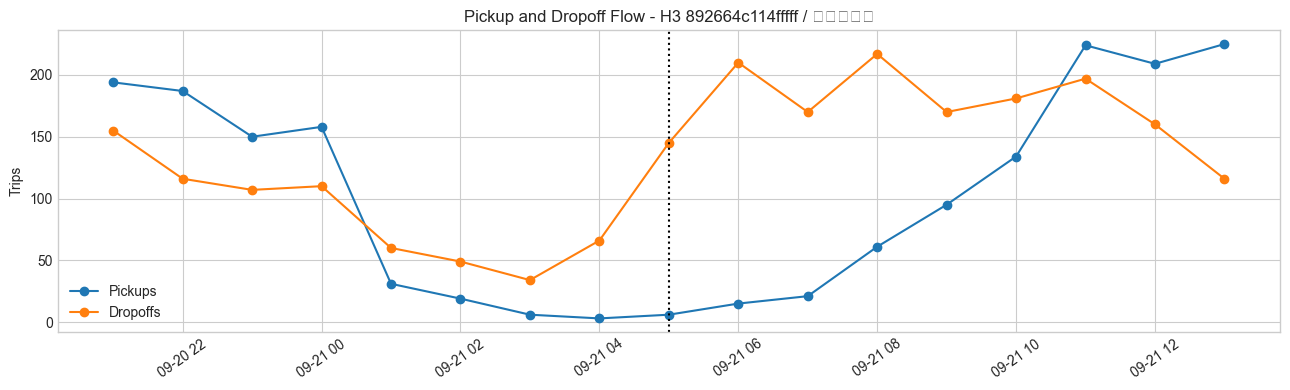

In [16]:
# Cell 16 - Relative supply-pressure proxy / 相对供给压力代理

# Positive net flow means more observed trip endings than starts in this H3-hour.
# 净流入为正表示该 H3 小时内观测到的结束行程多于开始行程。
model_df["net_flow"] = model_df["dropoff_count"] - model_df["pickup_count"]

net_baseline = (
    model_df[model_df["d"] < TRAIN_END]
    .groupby(["h3", "dow_sun0", "hour"])["net_flow"]
    .agg(expected_net_flow="mean", std_net_flow="std")
    .reset_index()
)
net_baseline["std_net_flow"] = net_baseline["std_net_flow"].replace(0, np.nan).fillna(1.0).clip(lower=1.0)
model_df = model_df.merge(net_baseline, on=["h3", "dow_sun0", "hour"], how="left")
model_df["supply_pressure_z"] = (
    (model_df["net_flow"] - model_df["expected_net_flow"]) / model_df["std_net_flow"]
)

flow_2024 = model_df[model_df["d"] >= TRAIN_END].copy()
top_net_inflow = flow_2024.nlargest(30, "supply_pressure_z")[[
    "h3", "timestamp", "pickup_count", "dropoff_count", "net_flow",
    "expected_net_flow", "supply_pressure_z", "pickup_z", "dropoff_z"
]]
top_net_outflow = flow_2024.nsmallest(30, "supply_pressure_z")[[
    "h3", "timestamp", "pickup_count", "dropoff_count", "net_flow",
    "expected_net_flow", "supply_pressure_z", "pickup_z", "dropoff_z"
]]

print("Top relative inflow / 最大相对净流入：")
display(top_net_inflow.head(15))
print("Top relative outflow / 最大相对净流出：")
display(top_net_outflow.head(15))

top_net_inflow.to_csv(OUTPUT_DIR / "top_relative_net_inflow_2024.csv", index=False)
top_net_outflow.to_csv(OUTPUT_DIR / "top_relative_net_outflow_2024.csv", index=False)

# This is not a true driver count. It only ranks unusual relative inflow/outflow.
# 这不是真实司机数量，只用于排列异常净流入/净流出的强弱。
example = top_net_inflow.iloc[0]
cell = example["h3"]
center = pd.Timestamp(example["timestamp"])
sub = flow_2024[
    (flow_2024["h3"] == cell)
    & flow_2024["timestamp"].between(center - pd.Timedelta(hours=8), center + pd.Timedelta(hours=8))
]

plt.figure(figsize=(13, 4))
plt.plot(sub["timestamp"], sub["pickup_count"], marker="o", label="Pickups")
plt.plot(sub["timestamp"], sub["dropoff_count"], marker="o", label="Dropoffs")
plt.axvline(center, color="black", linestyle=":")
plt.title(f"Pickup and Dropoff Flow - H3 {cell} / 上下车流动")
plt.ylabel("Trips")
plt.xticks(rotation=35)
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
# Cell 17 - Test whether flow features improve h+1 prediction / 测试流动特征是否改善一小时预测

flow_h1_metrics = run_model_experiment(
    "GBM base + pickup/dropoff flow / GBM 基础 + 上下车流动",
    1,
    base_features + flow_features,
)

flow_ablation = pd.DataFrame([
    model_runs[("GBM base dynamic / GBM 基础动态特征", 1)]["metrics"],
    flow_h1_metrics,
]).sort_values("MAE")

display(flow_ablation.round(4))
flow_ablation.to_csv(OUTPUT_DIR / "h1_flow_feature_ablation_metrics.csv", index=False)


,MAE,RMSE,R2,MAE_pct_of_mean,peak_accuracy,peak_precision,peak_recall,peak_F1,model,horizon_hours,test_rows,train_rows,fit_seconds
1,12.5431,23.6027,0.9449,13.470,0.9906,0.5431,0.2297,0.3229,GBM base + pickup/dropoff flow / GBM 基础 + 上下车流动,1,439100,875750,9.9016
0,13.0115,24.9376,0.9385,13.973,0.9903,0.5017,0.2131,0.2992,GBM base dynamic / GBM 基础动态特征,1,439100,875750,8.4026


## 9. Direction 4 - H3 neighbor spread and event-center candidates / 方向四：H3 周边扩散与事件中心候选

The neighbor feature is the total pickup count in the six first-ring H3 cells around each target cell.  
周边特征是目标 H3 一环六个邻居格子的 pickup 总量。

An event-center candidate should satisfy several conditions:

- the center cell is strongly above baseline;
- neighboring cells are also elevated or rise shortly afterward;
- the center is stronger or earlier than its neighbors.

事件中心候选需要同时满足：中心明显高于基线、周边同时或稍后上涨、中心比周边更强或更早。

This is regional localization, not building-level geolocation. The source centroids are privacy-processed, so using a finer H3 resolution would not create real additional precision.  
这只能做区域级定位，不能定位到具体建筑。原始 centroid 已做隐私处理，继续提高 H3 resolution 不会产生真实精度。


In [18]:
# Cell 18 - Neighbor baseline and spatial features / 周边基线与空间特征

neighbor_baseline = (
    model_df[model_df["d"] < TRAIN_END]
    .groupby(["h3", "dow_sun0", "hour"])
    .agg(
        expected_neighbor=("neighbor_pickup_count", "mean"),
        std_neighbor=("neighbor_pickup_count", "std"),
    )
    .reset_index()
)
neighbor_baseline["std_neighbor"] = neighbor_baseline["std_neighbor"].replace(0, np.nan).fillna(1.0).clip(lower=1.0)

model_df = model_df.merge(neighbor_baseline, on=["h3", "dow_sun0", "hour"], how="left")
model_df["neighbor_z"] = (
    (model_df["neighbor_pickup_count"] - model_df["expected_neighbor"]) / model_df["std_neighbor"]
)
model_df["neighbor_z_change_1h"] = model_df.groupby("h3")["neighbor_z"].diff()
model_df["neighbor_pickup_lag_1h"] = model_df.groupby("h3")["neighbor_pickup_count"].shift(1)
model_df["neighbor_pickup_lag_2h"] = model_df.groupby("h3")["neighbor_pickup_count"].shift(2)
model_df["neighbor_pickup_lag_3h"] = model_df.groupby("h3")["neighbor_pickup_count"].shift(3)
model_df["neighbor_z_lag_1h"] = model_df.groupby("h3")["neighbor_z"].shift(1)
model_df["neighbor_z_lag_2h"] = model_df.groupby("h3")["neighbor_z"].shift(2)

spatial_features = [
    "neighbor_pickup_count", "active_neighbor_cells", "expected_neighbor", "std_neighbor",
    "neighbor_z", "neighbor_z_change_1h", "neighbor_pickup_lag_1h",
    "neighbor_pickup_lag_2h", "neighbor_pickup_lag_3h", "neighbor_z_lag_1h",
    "neighbor_z_lag_2h",
]

print("Spatial features / 空间特征数量:", len(spatial_features))
display(model_df[["h3", "timestamp", "pickup_z", "neighbor_pickup_count", "neighbor_z", "neighbor_z_change_1h"]].head())
neighbor_baseline.to_csv(OUTPUT_DIR / "neighbor_baseline_train.csv", index=False)


Spatial features / 空间特征数量: 11


,h3,timestamp,pickup_z,neighbor_pickup_count,neighbor_z,neighbor_z_change_1h
0,892664520afffff,2022-01-01 00:00:00,-2.159450,0,-0.209524,NaN
1,892664520afffff,2022-01-01 01:00:00,-1.199558,0,-0.076190,0.133333
2,892664520afffff,2022-01-01 02:00:00,-0.703061,0,0.000000,0.076190
3,892664520afffff,2022-01-01 03:00:00,0.672634,0,0.000000,0.000000
4,892664520afffff,2022-01-01 04:00:00,-0.226667,0,-0.028571,-0.028571


In [19]:
# Cell 19 - Detect spatial propagation and event-center candidates / 检测空间扩散与事件中心候选

model_df["neighbor_z_future_1h"] = model_df.groupby("h3")["neighbor_z"].shift(-1)
model_df["neighbor_z_future_2h"] = model_df.groupby("h3")["neighbor_z"].shift(-2)
model_df["neighbor_growth_next_2h"] = (
    model_df[["neighbor_z_future_1h", "neighbor_z_future_2h"]].max(axis=1) - model_df["neighbor_z"]
)

model_df["spatial_spread_score"] = (
    model_df["pickup_z"].clip(lower=0)
    + 0.6 * model_df["neighbor_z"].clip(lower=0)
    + 0.4 * model_df["neighbor_growth_next_2h"].clip(lower=0)
)

candidate_mask = (
    (model_df["d"] >= TRAIN_END)
    & (model_df["pickup_z"] >= HIGH_Z_THRESHOLD)
    & (model_df["pickup_count"] >= MIN_PEAK_COUNT)
    & (model_df[["neighbor_z", "neighbor_z_future_1h", "neighbor_z_future_2h"]].max(axis=1) >= 2.0)
    & (model_df["pickup_z"] > model_df["neighbor_z"])
    & (model_df["is_dst_missing_hour"] == 0)
)

event_center_candidates = (
    model_df.loc[candidate_mask, [
        "h3", "timestamp", "pickup_count", "expected_pickup", "pickup_z",
        "neighbor_pickup_count", "expected_neighbor", "neighbor_z",
        "neighbor_z_future_1h", "neighbor_z_future_2h", "neighbor_growth_next_2h",
        "spatial_spread_score", "dropoff_count", "dropoff_z", "net_flow", "supply_pressure_z",
    ]]
    .sort_values("spatial_spread_score", ascending=False)
)

print("Event-center candidates / 事件中心候选数量:", len(event_center_candidates))
display(event_center_candidates.head(30))
event_center_candidates.head(500).to_csv(OUTPUT_DIR / "event_center_candidates_2024.csv", index=False)

# Test center-to-neighbor time relationship after removing normal patterns.
# 扣除正常规律后，测试中心异常是否领先周边异常。
propagation_rows = []
test_spatial = model_df[model_df["d"] >= TRAIN_END].copy()
for neighbor_delay in range(0, 4):
    neighbor_future = test_spatial.groupby("h3")["neighbor_z"].shift(-neighbor_delay)
    valid = test_spatial["pickup_z"].notna() & neighbor_future.notna()
    propagation_rows.append({
        "neighbor_delay_hours": neighbor_delay,
        "correlation_center_z_to_future_neighbor_z": test_spatial.loc[valid, "pickup_z"].corr(neighbor_future[valid]),
        "rows": int(valid.sum()),
    })

spatial_lag_correlation = pd.DataFrame(propagation_rows)
display(spatial_lag_correlation.round(4))
spatial_lag_correlation.to_csv(OUTPUT_DIR / "center_to_neighbor_lag_correlation_2024.csv", index=False)


Event-center candidates / 事件中心候选数量: 883


,h3,timestamp,pickup_count,expected_pickup,pickup_z,neighbor_pickup_count,expected_neighbor,neighbor_z,neighbor_z_future_1h,neighbor_z_future_2h,neighbor_growth_next_2h,spatial_spread_score,dropoff_count,dropoff_z,net_flow,supply_pressure_z
338737,892664c1ab3ffff,2024-08-20 01:00:00,270,4.730769,72.936239,346,50.269231,31.021764,10.742550,1.555416,-20.279214,91.549298,48,6.212222,-222,-38.458802
96434,892664c114fffff,2024-01-01 02:00:00,146,1.115385,45.670110,34,0.028846,33.971154,14.990385,2.855769,-18.980769,66.052803,177,34.195708,31,10.013176
333170,892664c1ab3ffff,2024-01-01 02:00:00,190,3.788462,39.758850,69,42.000000,2.122593,16.434187,8.921309,14.311595,46.757043,110,10.325225,-80,-11.692428
420840,892664c1b0bffff,2024-12-31 00:00:00,253,11.317308,34.183977,119,19.769231,19.643287,8.126276,2.709277,-11.517011,45.969949,70,3.376115,-183,-20.696944
517298,892664c1e33ffff,2024-01-01 02:00:00,197,4.586538,34.942397,56,2.836538,18.185949,9.774366,2.106517,-8.411583,45.853966,257,23.587967,60,8.016483
96433,892664c114fffff,2024-01-01 01:00:00,168,3.250000,25.179631,18,0.230769,17.769231,33.971154,14.990385,16.201923,42.321939,219,24.569007,51,10.705593
569907,892664c1e73ffff,2024-01-01 03:00:00,515,14.500000,26.564145,541,24.442308,21.631864,8.141126,3.309621,-13.490738,39.543263,200,19.931908,-315,-26.784556
338760,892664c1ab3ffff,2024-08-21 00:00:00,254,14.653846,30.687808,239,85.259615,9.884791,4.803064,6.051946,-3.832845,36.618682,85,5.250243,-169,-14.639691
338736,892664c1ab3ffff,2024-08-20 00:00:00,142,10.375000,22.025663,126,71.903846,4.104566,31.021764,10.742550,26.917198,35.255282,190,16.074168,48,4.488094
417698,892664c1b0bffff,2024-08-22 02:00:00,105,3.528846,30.528579,42,12.153846,7.785926,2.436783,0.389012,-5.349143,35.200135,119,13.959154,14,0.942998


,neighbor_delay_hours,correlation_center_z_to_future_neighbor_z,rows
0,0,0.1312,439200
1,1,0.1108,439150
2,2,0.0775,439100
3,3,0.0495,439050


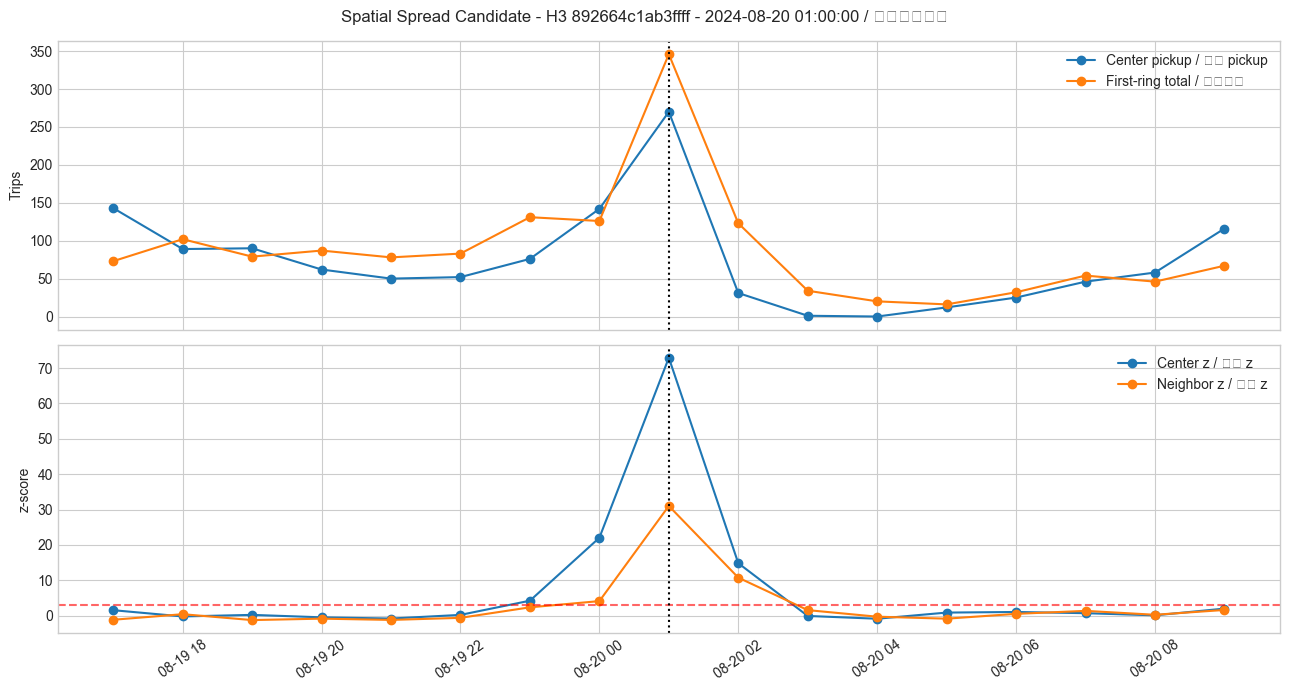

In [20]:
# Cell 20 - Visualize one spatial propagation candidate / 可视化一个空间扩散候选

if len(event_center_candidates) > 0:
    example = event_center_candidates.iloc[0]
    cell = example["h3"]
    center = pd.Timestamp(example["timestamp"])
    sub = model_df[
        (model_df["h3"] == cell)
        & model_df["timestamp"].between(center - pd.Timedelta(hours=8), center + pd.Timedelta(hours=8))
    ].copy()

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    axes[0].plot(sub["timestamp"], sub["pickup_count"], marker="o", label="Center pickup / 中心 pickup")
    axes[0].plot(sub["timestamp"], sub["neighbor_pickup_count"], marker="o", label="First-ring total / 一环总量")
    axes[0].axvline(center, color="black", linestyle=":")
    axes[0].set_ylabel("Trips")
    axes[0].legend()

    axes[1].plot(sub["timestamp"], sub["pickup_z"], marker="o", label="Center z / 中心 z")
    axes[1].plot(sub["timestamp"], sub["neighbor_z"], marker="o", label="Neighbor z / 周边 z")
    axes[1].axhline(3, color="red", linestyle="--", alpha=0.6)
    axes[1].axvline(center, color="black", linestyle=":")
    axes[1].set_ylabel("z-score")
    axes[1].legend()
    fig.suptitle(f"Spatial Spread Candidate - H3 {cell} - {center} / 空间扩散候选")
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()
else:
    print("No event-center candidate met the current thresholds. / 当前阈值下没有事件中心候选。")


In [21]:
# Cell 21 - Test spatial and combined features for h+1 forecast / 测试空间及组合特征的一小时预测

spatial_h1_metrics = run_model_experiment(
    "GBM base + H3 neighbors / GBM 基础 + H3 周边",
    1,
    base_features + spatial_features,
)

combined_h1_metrics = run_model_experiment(
    "GBM full flow + spatial / GBM 完整流动 + 空间",
    1,
    base_features + flow_features + spatial_features,
)

h1_feature_comparison = pd.DataFrame([
    model_runs[("GBM base dynamic / GBM 基础动态特征", 1)]["metrics"],
    model_runs[("GBM base + pickup/dropoff flow / GBM 基础 + 上下车流动", 1)]["metrics"],
    spatial_h1_metrics,
    combined_h1_metrics,
]).sort_values("MAE")

display(h1_feature_comparison.round(4))
h1_feature_comparison.to_csv(OUTPUT_DIR / "h1_feature_group_comparison.csv", index=False)


,MAE,RMSE,R2,MAE_pct_of_mean,peak_accuracy,peak_precision,peak_recall,peak_F1,model,horizon_hours,test_rows,train_rows,fit_seconds
3,12.5029,23.5551,0.9452,13.4268,0.9905,0.5347,0.2272,0.3188,GBM full flow + spatial / GBM 完整流动 + 空间,1,439100,875750,10.1556
1,12.5431,23.6027,0.9449,13.4700,0.9906,0.5431,0.2297,0.3229,GBM base + pickup/dropoff flow / GBM 基础 + 上下车流动,1,439100,875750,9.9016
2,12.9374,24.9458,0.9385,13.8934,0.9904,0.5163,0.2143,0.3029,GBM base + H3 neighbors / GBM 基础 + H3 周边,1,439100,875750,8.9131
0,13.0115,24.9376,0.9385,13.9730,0.9903,0.5017,0.2131,0.2992,GBM base dynamic / GBM 基础动态特征,1,439100,875750,8.4026


## 10. Final outputs and interpretation / 最终输出与解释

Focus on four questions after the notebook finishes:

1. Does the lag-sensitivity curve react enough when the current hour drops sharply?  
   当前小时大幅下降时，lag 敏感度曲线是否跟着明显下降？
2. How quickly does forecast quality decrease from 1 hour to 6 hours?  
   从未来 1 小时到 6 小时，预测质量下降多快？
3. Do dropoff features improve next-hour pickup prediction beyond pickup history alone?  
   加入 dropoff 后，是否比只用 pickup 历史更准确？
4. Do neighbor features improve prediction, and do spatial candidates show center-first, neighbor-later patterns?  
   周边 H3 特征是否改善预测？空间候选是否呈现中心先涨、周边后涨？

Correlation, feature importance, and proxy scores are not causal evidence. They identify patterns worth validating with event, driver-supply, and request-level data later.  
相关性、特征重要性和代理分数不代表因果关系。它们用于寻找值得以后结合活动、司机供给和请求数据继续验证的模式。


In [22]:
# Cell 22 - Save run summary and output manifest / 保存运行总结和输出清单

summary = {
    "analysis_table": ANALYSIS_TABLE,
    "top_h3_cells": TOP_N_CELLS,
    "train_period": "2022-01-01 to 2023-12-31",
    "test_period": "2024-01-01 to 2024-12-31",
    "complete_hourly_rows": int(len(hourly)),
    "high_peaks_2024": int(scored_2024["is_high_peak"].sum()),
    "low_anomalies_2024": int(scored_2024["is_low_anomaly"].sum()),
    "event_center_candidates_2024": int(len(event_center_candidates)),
    "best_base_model_by_horizon": (
        base_metrics[base_metrics["model"] == "GBM base dynamic / GBM 基础动态特征"]
        .sort_values("horizon_hours")
        .to_dict(orient="records")
    ),
    "h1_feature_comparison": h1_feature_comparison.to_dict(orient="records"),
}

summary_path = OUTPUT_DIR / "run_summary_hourly_sensitivity_flow_spatial.json"
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

output_manifest = pd.DataFrame({
    "output_file": sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file()),
})
display(output_manifest)
output_manifest.to_csv(OUTPUT_DIR / "output_manifest.csv", index=False)

print("Summary saved to / 总结已保存：", summary_path)
print("All outputs / 全部输出：", OUTPUT_DIR)


,output_file
0,best_dropoff_lead_by_h3_2024.csv
1,center_to_neighbor_lag_correlation_2024.csv
2,dropoff_to_pickup_cross_lag_correlation.csv
3,event_center_candidates_2024.csv
4,h1_base_feature_importance.csv
5,h1_feature_group_comparison.csv
6,h1_flow_feature_ablation_metrics.csv
7,h3_first_ring_neighbor_map.csv
8,hourly_dynamic_scores_2024.csv.gz
9,hourly_pickup_dropoff_baseline_train.csv


Summary saved to / 总结已保存： <project_dir>/notebook_outputs_hourly_sensitivity_flow_spatial/run_summary_hourly_sensitivity_flow_spatial.json
All outputs / 全部输出： <project_dir>/notebook_outputs_hourly_sensitivity_flow_spatial


In [23]:
# Cell 23 - Close MatrixOne connection / 关闭 MatrixOne 连接

conn.close()
print("Connection closed. / MatrixOne 连接已关闭。")


Connection closed. / MatrixOne 连接已关闭。
